# Dataset Merging Year Wise

In [18]:
# import pandas as pd
# import os

# # Define the folder containing the Excel files
# folder_path = r""


# # Get a list of all Excel files in the folder
# file_list = [f for f in os.listdir(folder_path) if f.endswith('.xlsx') or f.endswith('.csv')]

# # Initialize an empty list to store DataFrames
# df_list = []

# # Read each file and append to the list
# for file in file_list:
#     file_path = os.path.join(folder_path, file)
#     df = pd.read_excel(file_path) if file.endswith('.xlsx') else pd.read_csv(file_path)
#     df_list.append(df)

# # Merge all DataFrames into a single DataFrame
# merged_df = pd.concat(df_list, ignore_index=True)

# # Save the merged DataFrame to a new CSV file
# merged_csv_path = os.path.join(folder_path, "merged_traffic_data_2024.csv")
# merged_df.to_csv(merged_csv_path, index=False)

# print(f"✅ Merged dataset saved as: {merged_csv_path}")

# Data Loading and Preprocessing

In [19]:
#pip install geopy

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import folium
from geopy.distance import geodesic
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

import warnings

# Suppress all warnings
warnings.filterwarnings("ignore")

In [21]:
# Load Data
def load_data():
    files = ["merged_traffic_data_2022.csv", "merged_traffic_data_2023.csv", "merged_traffic_data_2024.csv"]
    data = pd.concat([pd.read_csv(file) for file in files], ignore_index=True)
    return data

In [22]:
# Preprocess Data
def preprocess_data(df):
    df['ts_generation'] = pd.to_datetime(df['ts_generation'], unit='ms')
    df['year'] = df['ts_generation'].dt.year
    df['month'] = df['ts_generation'].dt.month
    df['day'] = df['ts_generation'].dt.day
    df['hour'] = df['ts_generation'].dt.hour
    df['second'] = df['ts_generation'].dt.second
    return df

In [23]:
# Load and preprocess data
data = load_data()
data = preprocess_data(data)

print("✅ Data Loaded and Preprocessed")
data.head(100)

✅ Data Loaded and Preprocessed


,id,value,ontology_id,generated_by,property,geo_reference,additional_data,ts_generation,ts_insertion,Time,year,month,day,hour,second
0,12436,17653,3,53,in_count,"{""type"":""POINT"",""geo_data"":{""lat"":44.8066223 ,...",188305,2022-09-07 14:24:42.859,2022-09-07 16:24:43,NaN,2022,9,7,14,42
1,12437,569,4,53,in_avg_time,"{""type"":""POINT"",""geo_data"":{""lat"":44.8066223 ,...",188305,2022-09-07 14:24:42.859,2022-09-07 16:24:43,NaN,2022,9,7,14,42
2,12438,0,5,53,low_battery,"{""type"":""POINT"",""geo_data"":{""lat"":44.8066223 ,...",188305,2022-09-07 14:24:42.859,2022-09-07 16:24:43,NaN,2022,9,7,14,42
3,12523,17666,3,53,in_count,"{""type"":""POINT"",""geo_data"":{""lat"":44.8066223 ,...",188317,2022-09-07 14:39:42.883,2022-09-07 16:39:42,NaN,2022,9,7,14,42
4,12524,585,4,53,in_avg_time,"{""type"":""POINT"",""geo_data"":{""lat"":44.8066223 ,...",188317,2022-09-07 14:39:42.883,2022-09-07 16:39:42,NaN,2022,9,7,14,42
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,14689,0,5,53,low_battery,"{""type"":""POINT"",""geo_data"":{""lat"":44.8066223 ,...",188696,2022-09-07 23:39:43.473,2022-09-08 01:39:43,NaN,2022,9,7,23,43
96,14736,17847,3,53,in_count,"{""type"":""POINT"",""geo_data"":{""lat"":44.8066223 ,...",188706,2022-09-07 23:54:52.367,2022-09-08 01:54:52,NaN,2022,9,7,23,52
97,14737,0,4,53,in_avg_time,"{""type"":""POINT"",""geo_data"":{""lat"":44.8066223 ,...",188706,2022-09-07 23:54:52.367,2022-09-08 01:54:52,NaN,2022,9,7,23,52
98,14738,0,5,53,low_battery,"{""type"":""POINT"",""geo_data"":{""lat"":44.8066223 ,...",188706,2022-09-07 23:54:52.367,2022-09-08 01:54:52,NaN,2022,9,7,23,52


In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def preprocess_data(df):
    # Convert ts_generation to datetime, assuming Unix timestamps in milliseconds
    df['ts_generation'] = pd.to_datetime(df['ts_generation'], unit='ms')
    # Extract year, month, day, and hour for analysis
    df['year'] = df['ts_generation'].dt.year
    df['month'] = df['ts_generation'].dt.month
    df['day'] = df['ts_generation'].dt.day
    df['hour'] = df['ts_generation'].dt.hour
    return df

# 🔹 Step 2: Ensure timestamp is in datetime format
data['ts_generation'] = pd.to_datetime(data['ts_generation'])

# 🔹 Step 3: Function to add vehicle_diff with time gap check
def add_vehicle_diff(df, threshold=65535, max_time_gap_hours=6):
    df = df.copy()
    df['vehicle_diff'] = np.nan

    in_count_df = df[df['property'] == 'in_count'].copy()
    in_count_df = in_count_df.sort_values(['generated_by', 'ts_generation'])

    for sensor_id, group in in_count_df.groupby('generated_by'):
        values = group['value'].values
        timestamps = group['ts_generation'].values
        diffs = [0]  # First diff is always 0

        for i in range(1, len(values)):
            # Calculate time difference in hours
            time_diff = (timestamps[i] - timestamps[i-1]).astype('timedelta64[h]').astype(float)
            
            if time_diff > max_time_gap_hours:
                # Skip calculation if time gap exceeds 6 hours
                diffs.append(0)
            else:
                diff = values[i] - values[i-1]
                if diff < 0:
                    diff = values[i] + (threshold - values[i-1] + 1)
                diffs.append(diff)

        # Set the last diff to 0
        if len(diffs) > 1:
            diffs[-1] = 0

        df.loc[group.index, 'vehicle_diff'] = diffs

    return df

# 🔹 Step 4: Apply the function and save the result
modified_df = add_vehicle_diff(data)
modified_df.to_csv('traffic_data_with_vehicle_diff.csv', index=False)
print("✅ Modified dataset with vehicle_diff column saved as: traffic_data_with_vehicle_diff.csv")

# 🔹 Step 5: Display sample
print("\nSample of modified dataset:")
print(modified_df[modified_df['property'] == 'in_count'].head(4))

# 🔹 Step 6: Function to plot yearly trends
def plot_traffic_trends(df):
    df = df[df['property'] == 'in_count'].copy()
    df['year'] = df['ts_generation'].dt.year
    sensors = df['generated_by'].unique()

    plt.figure(figsize=(15, len(sensors) * 5))

    for i, sensor in enumerate(sensors, 1):
        sensor_data = df[df['generated_by'] == sensor]
        yearly_data = sensor_data.groupby('year')['vehicle_diff'].mean().reset_index()

        plt.subplot(len(sensors), 1, i)
        sns.lineplot(data=yearly_data, x='year', y='vehicle_diff', marker='o')
        plt.title(f'Traffic Trend for Sensor {sensor} (Average Vehicle Count per Interval)')
        plt.xlabel('Year')
        plt.ylabel('Average Vehicle Count per Interval')
        plt.grid(True)

    plt.tight_layout()
    plt.savefig('sensor_traffic_trends_vehicle_diff.png')
    plt.show()
    print("✅ Traffic trend plots saved as: sensor_traffic_trends_vehicle_diff.png")

# 🔹 Step 7: Optionally plot the trends (uncomment to run)
#plot_traffic_trends(modified_df)


✅ Modified dataset with vehicle_diff column saved as: traffic_data_with_vehicle_diff.csv

Sample of modified dataset:
      id  value  ontology_id  generated_by  property  \
0  12436  17653            3            53  in_count   
3  12523  17666            3            53  in_count   
6  12589  17673            3            53  in_count   
9  12735  17687            3            53  in_count   

                                       geo_reference  additional_data  \
0  {"type":"POINT","geo_data":{"lat":44.8066223 ,...           188305   
3  {"type":"POINT","geo_data":{"lat":44.8066223 ,...           188317   
6  {"type":"POINT","geo_data":{"lat":44.8066223 ,...           188328   
9  {"type":"POINT","geo_data":{"lat":44.8066223 ,...           188350   

            ts_generation         ts_insertion  Time  year  month  day  hour  \
0 2022-09-07 14:24:42.859  2022-09-07 16:24:43   NaN  2022      9    7    14   
3 2022-09-07 14:39:42.883  2022-09-07 16:39:42   NaN  2022      9    7    1

In [25]:
# Load and preprocess data
data = load_data()
data = preprocess_data(data)
data = add_vehicle_diff(data)


print("✅ Data Loaded and Preprocessed")
data.head(100)

✅ Data Loaded and Preprocessed


,id,value,ontology_id,generated_by,property,geo_reference,additional_data,ts_generation,ts_insertion,Time,year,month,day,hour,vehicle_diff
0,12436,17653,3,53,in_count,"{""type"":""POINT"",""geo_data"":{""lat"":44.8066223 ,...",188305,2022-09-07 14:24:42.859,2022-09-07 16:24:43,NaN,2022,9,7,14,0.0
1,12437,569,4,53,in_avg_time,"{""type"":""POINT"",""geo_data"":{""lat"":44.8066223 ,...",188305,2022-09-07 14:24:42.859,2022-09-07 16:24:43,NaN,2022,9,7,14,NaN
2,12438,0,5,53,low_battery,"{""type"":""POINT"",""geo_data"":{""lat"":44.8066223 ,...",188305,2022-09-07 14:24:42.859,2022-09-07 16:24:43,NaN,2022,9,7,14,NaN
3,12523,17666,3,53,in_count,"{""type"":""POINT"",""geo_data"":{""lat"":44.8066223 ,...",188317,2022-09-07 14:39:42.883,2022-09-07 16:39:42,NaN,2022,9,7,14,13.0
4,12524,585,4,53,in_avg_time,"{""type"":""POINT"",""geo_data"":{""lat"":44.8066223 ,...",188317,2022-09-07 14:39:42.883,2022-09-07 16:39:42,NaN,2022,9,7,14,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,14689,0,5,53,low_battery,"{""type"":""POINT"",""geo_data"":{""lat"":44.8066223 ,...",188696,2022-09-07 23:39:43.473,2022-09-08 01:39:43,NaN,2022,9,7,23,NaN
96,14736,17847,3,53,in_count,"{""type"":""POINT"",""geo_data"":{""lat"":44.8066223 ,...",188706,2022-09-07 23:54:52.367,2022-09-08 01:54:52,NaN,2022,9,7,23,0.0
97,14737,0,4,53,in_avg_time,"{""type"":""POINT"",""geo_data"":{""lat"":44.8066223 ,...",188706,2022-09-07 23:54:52.367,2022-09-08 01:54:52,NaN,2022,9,7,23,NaN
98,14738,0,5,53,low_battery,"{""type"":""POINT"",""geo_data"":{""lat"":44.8066223 ,...",188706,2022-09-07 23:54:52.367,2022-09-08 01:54:52,NaN,2022,9,7,23,NaN


In [26]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1604838 entries, 0 to 1604837
Data columns (total 15 columns):
 #   Column           Non-Null Count    Dtype         
---  ------           --------------    -----         
 0   id               1604838 non-null  int64         
 1   value            1604838 non-null  int64         
 2   ontology_id      1604838 non-null  int64         
 3   generated_by     1604838 non-null  int64         
 4   property         1604838 non-null  object        
 5   geo_reference    1602624 non-null  object        
 6   additional_data  1604838 non-null  int64         
 7   ts_generation    1604838 non-null  datetime64[ns]
 8   ts_insertion     1604838 non-null  object        
 9   Time             661335 non-null   float64       
 10  year             1604838 non-null  int32         
 11  month            1604838 non-null  int32         
 12  day              1604838 non-null  int32         
 13  hour             1604838 non-null  int32         
 14  ve

# 1.TRAFFIC PATTERN ANALYSIS

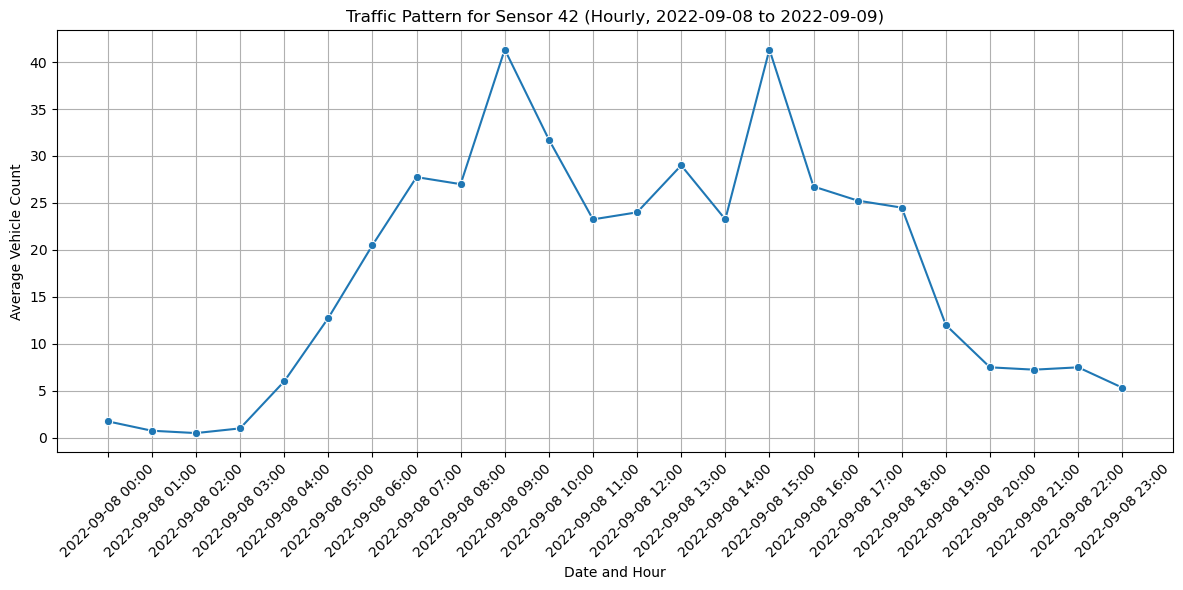

✅ Traffic pattern plot for sensor 42 saved as: sensor_42_traffic_pattern_2022-09-08_to_2022-09-09.png


In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def plot_traffic_patterns(df, sensor_id, start_date, end_date, time_granularity='hour'):
    """
    Plot traffic patterns for a specific sensor within a given time period.
    
    Parameters:
    - df: DataFrame containing the data with vehicle_diff column
    - sensor_id: The ID of the sensor (generated_by)
    - start_date: Start date of the time period (e.g., '2022-09-01')
    - end_date: End date of the time period (e.g., '2022-09-30')
    - time_granularity: Granularity of time axis ('hour', 'day', or 'month')
    """
    # Filter for in_count and the specific sensor
    df = df[(df['property'] == 'in_count') & (df['generated_by'] == sensor_id)].copy()
    
    # Convert ts_generation to datetime if it isn't already
    if pd.api.types.is_numeric_dtype(df['ts_generation']):
        # If ts_generation is numeric (Unix timestamps in milliseconds), convert to datetime
        df['ts_generation'] = pd.to_datetime(df['ts_generation'], unit='ms')
    elif not pd.api.types.is_datetime64_any_dtype(df['ts_generation']):
        # If ts_generation is not numeric but also not datetime (e.g., string), try converting
        df['ts_generation'] = pd.to_datetime(df['ts_generation'])
    
    # Convert start_date and end_date to datetime
    start_date = pd.to_datetime(start_date)
    end_date = pd.to_datetime(end_date)
    
    # Filter data for the specified time period
    df = df[(df['ts_generation'] >= start_date) & (df['ts_generation'] <= end_date)]
    
    if df.empty:
        print(f"No data found for sensor {sensor_id} in the specified time period.")
        return
    
    # Prepare data based on time granularity
    if time_granularity == 'hour':
        df['time_unit'] = df['ts_generation'].dt.strftime('%Y-%m-%d %H:00')
        x_label = 'Date and Hour'
        title = f'Traffic Pattern for Sensor {sensor_id} (Hourly, {start_date.date()} to {end_date.date()})'
    elif time_granularity == 'day':
        df['time_unit'] = df['ts_generation'].dt.strftime('%Y-%m-%d')
        x_label = 'Date'
        title = f'Traffic Pattern for Sensor {sensor_id} (Daily, {start_date.date()} to {end_date.date()})'
    elif time_granularity == 'month':
        df['time_unit'] = df['ts_generation'].dt.strftime('%Y-%m')
        x_label = 'Year-Month'
        title = f'Traffic Pattern for Sensor {sensor_id} (Monthly, {start_date.date()} to {end_date.date()})'
    else:
        raise ValueError("time_granularity must be 'hour', 'day', or 'month'")
    
    # Group by time unit and calculate mean vehicle_diff
    grouped_data = df.groupby('time_unit')['vehicle_diff'].mean().reset_index()
    
    # Plot the data
    plt.figure(figsize=(12, 6))
    sns.lineplot(data=grouped_data, x='time_unit', y='vehicle_diff', marker='o')
    plt.title(title)
    plt.xlabel(x_label)
    plt.ylabel('Average Vehicle Count')
    plt.xticks(rotation=45)
    plt.grid(True)
    plt.tight_layout()

    
    # Save the plot
    output_file = f'sensor_{sensor_id}_traffic_pattern_{start_date.date()}_to_{end_date.date()}.png'
    plt.savefig(output_file)
    plt.show()
    print(f"✅ Traffic pattern plot for sensor {sensor_id} saved as: {output_file}")

# Example: Plot traffic patterns for sensor 53 from 2022-09-01 to 2022-09-30 (hourly)
plot_traffic_patterns(
    df=modified_df,
    sensor_id=42,
    start_date='2022-09-08',
    end_date='2022-09-09',
    time_granularity='hour'  # Options: 'hour', 'day', or 'month'
)

Initial DataFrame shape: (1604838, 16)
Available sensors: [53 51 43 42 52 46 44 45 49 47 54]
Time range in DataFrame: 2022-09-07 14:18:59.837000 to 2024-12-22 17:53:20
After filtering for property == 'in_count' and generated_by == 42, shape: (39877, 16)
Time range for sensor 42: 2022-09-07 14:29:59.041000 to 2024-12-22 17:53:20
After filtering for time period (2022-01-01 00:00:00 to 2024-12-31 00:00:00), shape: (39877, 16)
Grouped data shape: (20, 4)


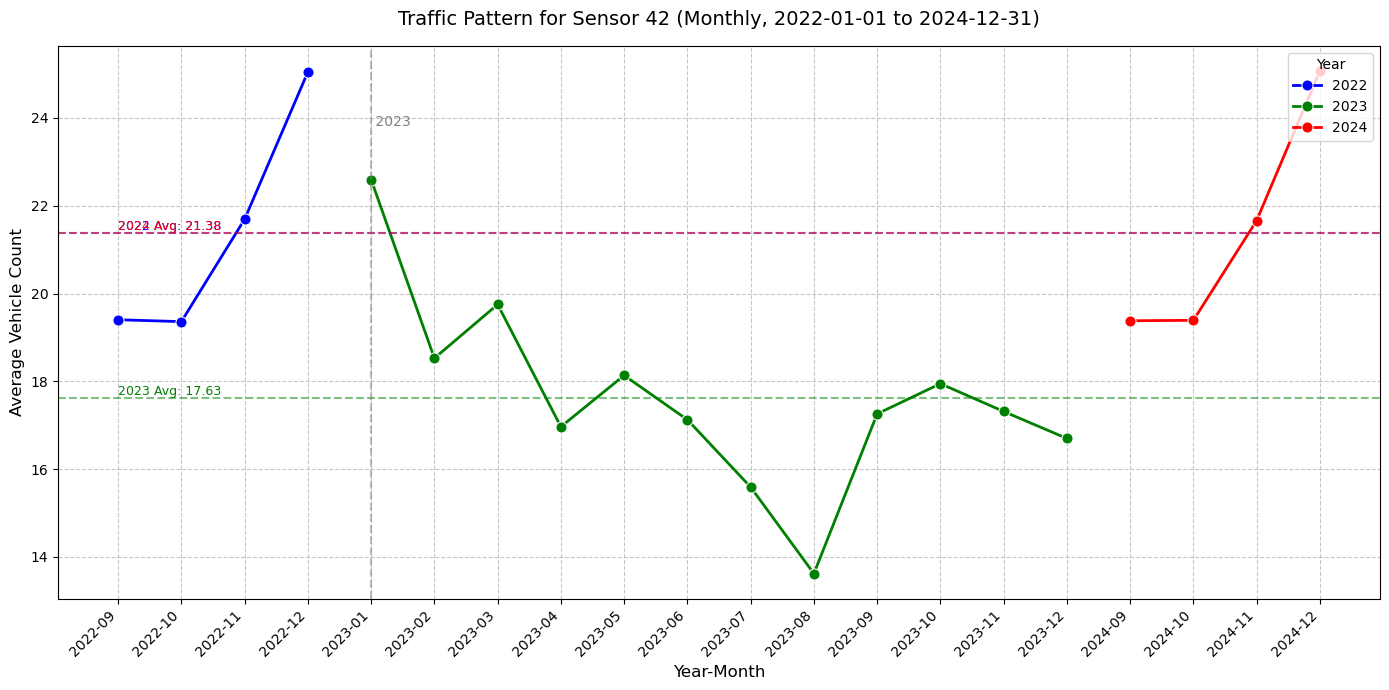

✅ Traffic pattern plot for sensor 42

Yearly Average Vehicle Counts for Sensor 42
 - 2022: 21.38
 - 2023: 17.63
 - 2024: 21.38


In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def plot_sensor_traffic_patterns_single_graph(df, sensor_id, start_date='2022-01-01', end_date='2024-12-31', time_granularity='month'):
    """
    Plot traffic patterns for a specific sensor in a single graph,
    with different colors for each year and a legend.
    
    Parameters:
    - df: DataFrame containing the data with vehicle_diff column
    - sensor_id: The ID of the sensor (generated_by)
    - start_date: Start date of the time period (e.g., '2022-01-01')
    - end_date: End date of the time period (e.g., '2024-12-31')
    - time_granularity: Granularity of time axis ('month' recommended; 'day' supported)
    """
    print(f"Initial DataFrame shape: {df.shape}")
    print(f"Available sensors: {df['generated_by'].unique()}")
    print(f"Time range in DataFrame: {df['ts_generation'].min()} to {df['ts_generation'].max()}")
    
    # Filter for in_count and the specific sensor
    df = df[(df['property'] == 'in_count') & (df['generated_by'] == sensor_id)].copy()
    print(f"After filtering for property == 'in_count' and generated_by == {sensor_id}, shape: {df.shape}")
    
    if not df.empty:
        print(f"Time range for sensor {sensor_id}: {df['ts_generation'].min()} to {df['ts_generation'].max()}")
    
    # Convert start_date and end_date to datetime
    start_date = pd.to_datetime(start_date)
    end_date = pd.to_datetime(end_date)
    
    # Convert ts_generation to datetime (it's in milliseconds)
    if pd.api.types.is_numeric_dtype(df['ts_generation']):
        df['ts_generation'] = pd.to_datetime(df['ts_generation'], unit='ms')
    else:
        df['ts_generation'] = pd.to_datetime(df['ts_generation'])
    
    # Filter data for the specified time period
    df = df[(df['ts_generation'] >= start_date) & (df['ts_generation'] <= end_date)]
    print(f"After filtering for time period ({start_date} to {end_date}), shape: {df.shape}")
    
    if df.empty:
        print(f"No data found for sensor {sensor_id} in the specified time period ({start_date.date()} to {end_date.date()}).")
        return
    
    # Prepare data based on time granularity
    if time_granularity == 'month':
        df['year'] = df['ts_generation'].dt.year
        df['year_month'] = df['ts_generation'].dt.strftime('%Y-%m')
        df['month_name'] = df['ts_generation'].dt.strftime('%b')  # Abbreviated month name (e.g., Jan, Feb)
        x_label = 'Year-Month'
        title = f'Traffic Pattern for Sensor {sensor_id} (Monthly, {start_date.date()} to {end_date.date()})'
        time_unit = 'year_month'
    elif time_granularity == 'day':
        df['year'] = df['ts_generation'].dt.year
        df['year_month'] = df['ts_generation'].dt.strftime('%Y-%m-%d')
        df['month_name'] = df['ts_generation'].dt.strftime('%Y-%m-%d')
        x_label = 'Date'
        title = f'Traffic Pattern for Sensor {sensor_id} (Daily, {start_date.date()} to {end_date.date()})'
        time_unit = 'year_month'
    else:
        raise ValueError("time_granularity must be 'day' or 'month'")
    
    # Group by year and year_month, calculate mean vehicle_diff
    grouped_data = df.groupby(['year', 'year_month', 'month_name'])['vehicle_diff'].mean().reset_index()
    print(f"Grouped data shape: {grouped_data.shape}")
    
    # Define colors for each year (include 2025)
    year_colors = {2022: 'blue', 2023: 'green', 2024: 'red', 2025: 'purple'}
    
    # Create a single plot
    plt.figure(figsize=(14, 7))
    
    # Plot each year's data with a different color
    sns.lineplot(
        data=grouped_data,
        x='year_month',
        y='vehicle_diff',
        hue='year',
        palette=year_colors,
        marker='o',
        linewidth=2,
        markersize=8
    )
    
    # Calculate and plot yearly averages
    yearly_averages = grouped_data.groupby('year')['vehicle_diff'].mean().to_dict()
    for year, avg in yearly_averages.items():
        plt.axhline(y=avg, color=year_colors[year], linestyle='--', alpha=0.5)
        plt.text(grouped_data['year_month'].iloc[0], avg, f'{year} Avg: {avg:.2f}', fontsize=9, color=year_colors[year], verticalalignment='bottom')
    
    # Add yearly boundaries (include 2025)
    for year in range(2022, 2026):  # Updated to include 2025
        year_start = f'{year}-01'
        if year_start in grouped_data['year_month'].values:
            plt.axvline(x=year_start, color='gray', linestyle='--', alpha=0.5)
            plt.text(year_start, grouped_data['vehicle_diff'].max() * 0.95, f' {year}', fontsize=10, color='gray')
    
    # Customize plot
    plt.title(title, fontsize=14, pad=15)
    plt.xlabel(x_label, fontsize=12)
    plt.ylabel('Average Vehicle Count', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.legend(title='Year', loc='upper right', fontsize=10)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()

    # Show the plot
    plt.show()
    print(f"✅ Traffic pattern plot for sensor {sensor_id}")
    
    # Print yearly averages (include 2025)
    print("\nYearly Average Vehicle Counts for Sensor", sensor_id)
    for year in [2022, 2023, 2024, 2025]:
        year_data = grouped_data[grouped_data['year'] == year]
        if not year_data.empty:
            avg = year_data['vehicle_diff'].mean()
            print(f" - {year}: {avg:.2f}")

# Run with updated end_date
plot_sensor_traffic_patterns_single_graph(
    df=modified_df,
    sensor_id=42,
    start_date='2022-01-01',
    end_date='2024-12-31',  # Include data up to current date
    time_granularity='month'
)

In [29]:
data[data['generated_by'] == 42][['ts_generation']].sort_values('ts_generation').head(10)


,ts_generation
52773,2022-09-07 14:29:59.041
52774,2022-09-07 14:29:59.041
52775,2022-09-07 14:29:59.041
52776,2022-09-07 14:44:59.051
52777,2022-09-07 14:44:59.051
52778,2022-09-07 14:44:59.051
52779,2022-09-07 14:59:59.052
52780,2022-09-07 14:59:59.052
52781,2022-09-07 14:59:59.052
52782,2022-09-07 15:14:59.079


# 2. SPEED ANALYSIS

In [30]:
print(data.columns)

Index(['id', 'value', 'ontology_id', 'generated_by', 'property',
       'geo_reference', 'additional_data', 'ts_generation', 'ts_insertion',
       'Time', 'year', 'month', 'day', 'hour', 'vehicle_diff'],
      dtype='object')


In [31]:
import pandas as pd

# Function to count speed occurrences within a range (in km/h)
def count_speed_occurrences_range(df, sensor_id, min_speed_kmh, max_speed_kmh, date):
    df_sensor = df[(df['generated_by'] == sensor_id) & (df['property'] == 'in_avg_time')].copy()

    # Calculate Speed in km/h
    df_sensor['speed_kmh'] = (3.5 / (df_sensor['value'] / 1000)) * 3.6  

    # Filter by Date
    df_filtered = df_sensor[df_sensor['ts_generation'].dt.date == pd.to_datetime(date).date()]

    # Count occurrences where speed falls within the specified range (in km/h)
    count = df_filtered[(df_filtered['speed_kmh'] >= min_speed_kmh) & (df_filtered['speed_kmh'] <= max_speed_kmh)].shape[0]

    print(f"Speed between {min_speed_kmh} km/h and {max_speed_kmh} km/h was detected {count} times on {date} by sensor {sensor_id}.")


In [32]:
# Example Usage
count_speed_occurrences_range(data, sensor_id=42, min_speed_kmh=20, max_speed_kmh=30, date="2022-09-08")

Speed between 20 km/h and 30 km/h was detected 42 times on 2022-09-08 by sensor 42.


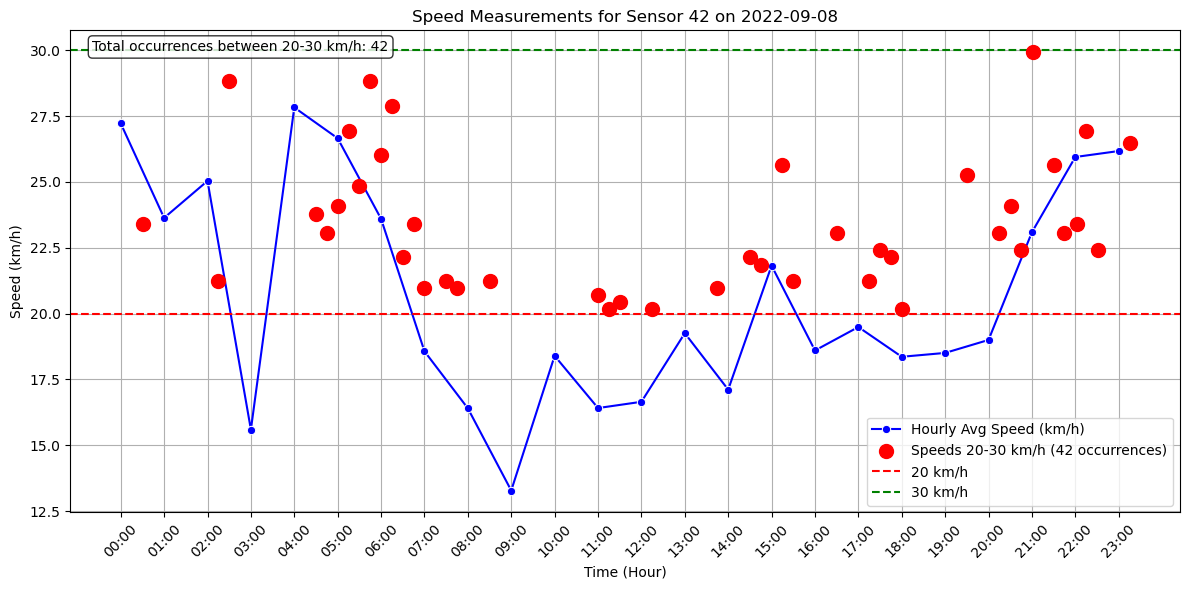

Timestamps of speeds between 20-30 km/h:
 - 2022-09-08 00:30:20: 23.42 km/h
 - 2022-09-08 02:15:00: 21.25 km/h
 - 2022-09-08 02:30:24: 28.83 km/h
 - 2022-09-08 04:30:23: 23.77 km/h
 - 2022-09-08 04:45:00: 23.08 km/h
 - 2022-09-08 04:59:59: 24.09 km/h
 - 2022-09-08 05:14:59: 26.92 km/h
 - 2022-09-08 05:29:59: 24.85 km/h
 - 2022-09-08 05:44:59: 28.83 km/h
 - 2022-09-08 05:59:59: 26.03 km/h
 - 2022-09-08 06:14:59: 27.88 km/h
 - 2022-09-08 06:29:59: 22.14 km/h
 - 2022-09-08 06:44:59: 23.42 km/h
 - 2022-09-08 06:59:59: 20.97 km/h
 - 2022-09-08 07:29:59: 21.25 km/h
 - 2022-09-08 07:44:59: 20.97 km/h
 - 2022-09-08 08:29:59: 21.25 km/h
 - 2022-09-08 10:59:59: 20.72 km/h
 - 2022-09-08 11:14:59: 20.19 km/h
 - 2022-09-08 11:29:59: 20.45 km/h
 - 2022-09-08 12:14:59: 20.19 km/h
 - 2022-09-08 13:45:00: 20.97 km/h
 - 2022-09-08 14:30:00: 22.14 km/h
 - 2022-09-08 14:45:00: 21.84 km/h
 - 2022-09-08 15:15:00: 25.66 km/h
 - 2022-09-08 15:30:00: 21.25 km/h
 - 2022-09-08 16:30:00: 23.08 km/h
 - 2022-09-08 

In [33]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def plot_speed_distribution_hourly(df, sensor_id, min_speed_kmh, max_speed_kmh, date):
    # Ensure timestamp is in datetime format
    df['ts_generation'] = pd.to_datetime(df['ts_generation'])

    # Filter for the specific sensor and property
    df_sensor = df.loc[
        (df['generated_by'] == sensor_id) & (df['property'] == 'in_avg_time')
    ]

    if df_sensor.empty:
        print(f"No data found for sensor {sensor_id}.")
        return

    # Avoid division by zero
    df_sensor = df_sensor[df_sensor['value'] > 0]

    # Calculate Speed in km/h
    df_sensor.loc[:, 'speed_kmh'] = (3.5 / (df_sensor['value'] / 1000)) * 3.6  

    # Filter by Date
    df_filtered = df_sensor[df_sensor['ts_generation'].dt.date == pd.to_datetime(date).date()]

    if df_filtered.empty:
        print(f"No data found for sensor {sensor_id} on {date}.")
        return

    # Select only relevant numeric columns before resampling
    df_filtered = df_filtered[['ts_generation', 'speed_kmh']].copy()

    # Resampling data to show one value per hour (numeric-only) for the line plot
    df_hourly = df_filtered.set_index('ts_generation').resample('H').mean(numeric_only=True).reset_index()

    # Filter points within the specified speed range (20-30 km/h) for highlighting
    df_highlight = df_filtered[
        (df_filtered['speed_kmh'] >= min_speed_kmh) & (df_filtered['speed_kmh'] <= max_speed_kmh)
    ]

    # Count occurrences in the specified speed range
    occurrences = len(df_highlight)

    # Plot speed values over time
    plt.figure(figsize=(12, 6))
    sns.lineplot(data=df_hourly, x='ts_generation', y='speed_kmh', marker='o', label='Hourly Avg Speed (km/h)', color='blue')

    # Highlight individual points within the specified speed range
    if not df_highlight.empty:
        plt.scatter(
            df_highlight['ts_generation'], 
            df_highlight['speed_kmh'], 
            color='red', 
            s=100, 
            label=f'Speeds {min_speed_kmh}-{max_speed_kmh} km/h ({occurrences} occurrences)', 
            zorder=5
        )

    # Highlight the specified speed range boundaries
    plt.axhline(min_speed_kmh, color='red', linestyle='--', label=f'{min_speed_kmh} km/h')
    plt.axhline(max_speed_kmh, color='green', linestyle='--', label=f'{max_speed_kmh} km/h')

    # Format x-axis to show hourly timestamps
    plt.xticks(df_hourly['ts_generation'], df_hourly['ts_generation'].dt.strftime('%H:%M'), rotation=45)

    # Plot formatting
    plt.xlabel("Time (Hour)")
    plt.ylabel("Speed (km/h)")
    plt.title(f"Speed Measurements for Sensor {sensor_id} on {date}")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()

    # Add annotation for total occurrences
    if occurrences > 0:
        plt.text(
            0.02, 0.98, 
            f'Total occurrences between {min_speed_kmh}-{max_speed_kmh} km/h: {occurrences}', 
            transform=plt.gca().transAxes, 
            fontsize=10, 
            verticalalignment='top', 
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8)
        )

    plt.show()

    # Print timestamps of highlighted occurrences
    if not df_highlight.empty:
        print(f"Timestamps of speeds between {min_speed_kmh}-{max_speed_kmh} km/h:")
        for ts, speed in zip(df_highlight['ts_generation'], df_highlight['speed_kmh']):
            print(f" - {ts.strftime('%Y-%m-%d %H:%M:%S')}: {speed:.2f} km/h")
    else:
        print(f"No speeds found between {min_speed_kmh}-{max_speed_kmh} km/h.")

# Example Usage
plot_speed_distribution_hourly(data, sensor_id=42, min_speed_kmh=20, max_speed_kmh=30, date="2022-09-08")

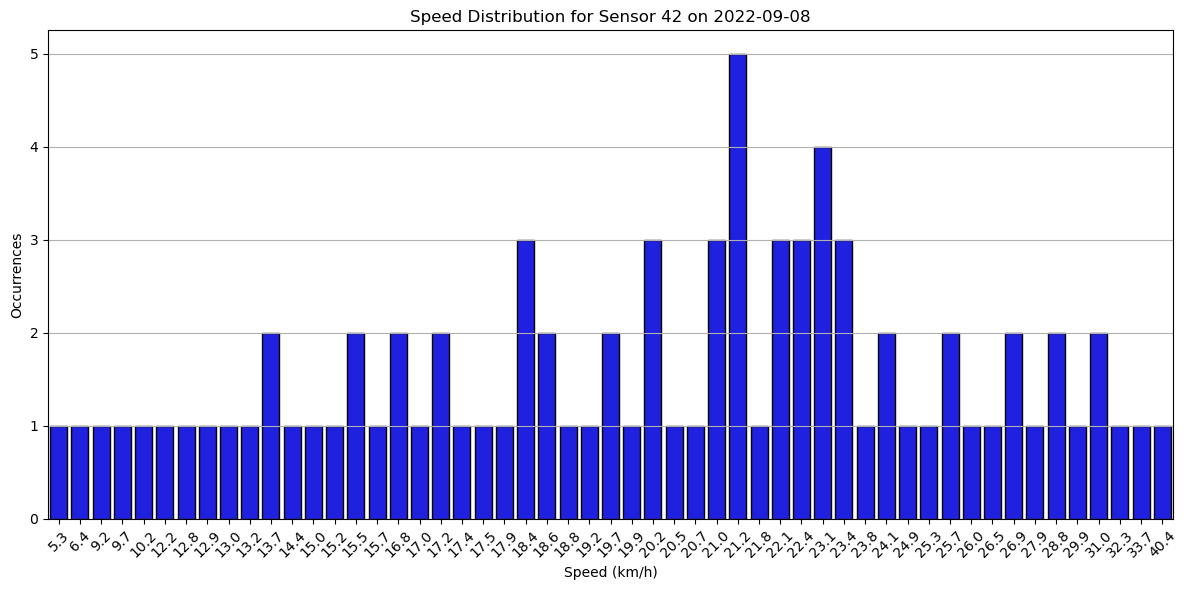

In [34]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import logging

# Suppress the specific INFO-level warning from Matplotlib
logging.getLogger('matplotlib.category').setLevel(logging.WARNING)

def plot_speed_occurrences(df, sensor_id, date):
    # Ensure timestamp is in datetime format
    df['ts_generation'] = pd.to_datetime(df['ts_generation'])

    # Filter for the specific sensor and property
    df_sensor = df[(df['generated_by'] == sensor_id) & (df['property'] == 'in_avg_time')].copy()

    if df_sensor.empty:
        print(f"No data found for sensor {sensor_id}.")
        return

    # Avoid division by zero
    df_sensor = df_sensor[df_sensor['value'] > 0]

    # Calculate Speed in km/h
    df_sensor['speed_kmh'] = (3.5 / (df_sensor['value'] / 1000)) * 3.6  

    # Filter by Date
    df_filtered = df_sensor[df_sensor['ts_generation'].dt.date == pd.to_datetime(date).date()]

    if df_filtered.empty:
        print(f"No data found for sensor {sensor_id} on {date}.")
        return

    # Round speed values and ensure numeric type
    df_filtered['speed_kmh'] = df_filtered['speed_kmh'].round(1)
    df_filtered['speed_kmh'] = pd.to_numeric(df_filtered['speed_kmh'], errors='coerce')

    # Drop any NaN values
    df_filtered = df_filtered.dropna(subset=['speed_kmh'])

    # Count occurrences of each speed value
    speed_counts = df_filtered['speed_kmh'].value_counts().reset_index()
    speed_counts.columns = ['speed_kmh', 'count']

    # Sort by speed for better visualization
    speed_counts = speed_counts.sort_values('speed_kmh')

    # Ensure speed_kmh is numeric in speed_counts
    speed_counts['speed_kmh'] = pd.to_numeric(speed_counts['speed_kmh'], errors='coerce')

    # Plot bar plot
    plt.figure(figsize=(12, 6))
    sns.barplot(data=speed_counts, x='speed_kmh', y='count', color='blue', edgecolor='black')

    # Add labels and title
    plt.xlabel("Speed (km/h)")
    plt.ylabel("Occurrences")
    plt.title(f"Speed Distribution for Sensor {sensor_id} on {date}")

    # Rotate x-axis labels for better readability and ensure numeric display
    plt.xticks(ticks=range(len(speed_counts['speed_kmh'])), 
               labels=[f'{x:.1f}' for x in speed_counts['speed_kmh']], 
               rotation=45)

    # Show the plot
    plt.grid(True, axis='y')
    plt.tight_layout()
    plt.show()

# Example Usage
plot_speed_occurrences(data, sensor_id=42, date="2022-09-08")

# 3. ML-BASED TRAFFIC PREDICTION

## Traffic Regression Model

In [35]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

In [36]:
print(data.columns)

Index(['id', 'value', 'ontology_id', 'generated_by', 'property',
       'geo_reference', 'additional_data', 'ts_generation', 'ts_insertion',
       'Time', 'year', 'month', 'day', 'hour', 'vehicle_diff'],
      dtype='object')


In [37]:
print(data[['ts_generation', 'year', 'month', 'day', 'hour']].head())

            ts_generation  year  month  day  hour
0 2022-09-07 14:24:42.859  2022      9    7    14
1 2022-09-07 14:24:42.859  2022      9    7    14
2 2022-09-07 14:24:42.859  2022      9    7    14
3 2022-09-07 14:39:42.883  2022      9    7    14
4 2022-09-07 14:39:42.883  2022      9    7    14


In [38]:
# Ensure ts_generation is in datetime format
data['ts_generation'] = pd.to_datetime(data['ts_generation'])

# Extract seconds from ts_generation
data['seconds'] = data['ts_generation'].dt.second

# Display the requested columns plus seconds
print(data[['ts_generation', 'year', 'month', 'day', 'hour','seconds']].head())

            ts_generation  year  month  day  hour  seconds
0 2022-09-07 14:24:42.859  2022      9    7    14       42
1 2022-09-07 14:24:42.859  2022      9    7    14       42
2 2022-09-07 14:24:42.859  2022      9    7    14       42
3 2022-09-07 14:39:42.883  2022      9    7    14       42
4 2022-09-07 14:39:42.883  2022      9    7    14       42


In [39]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor
import seaborn as sns
import matplotlib.pyplot as plt

# Data Preprocessing
data['ts_generation'] = pd.to_datetime(data['ts_generation'])
data['vehicle_diff'] = data['vehicle_diff'].clip(data['vehicle_diff'].quantile(0.01), data['vehicle_diff'].quantile(0.99))  # Clip outliers

def prepare_ml_data(df):
    # Filter for 'in_count' property
    df_ml = df[df['property'] == "in_count"].copy()
    
    # Temporal features
    df_ml['weekday'] = df_ml['ts_generation'].dt.weekday
    df_ml['is_weekend'] = df_ml['weekday'].isin([5, 6]).astype(int)
    df_ml['is_rush_hour'] = df_ml['hour'].isin([7, 8, 9, 10, 16, 17, 18, 19]).astype(int)
    
    # Features and target
    X = df_ml[['year', 'month', 'day', 'hour','minute','seconds', 'is_weekend', 'is_rush_hour', 'generated_by']]
    y = df_ml['vehicle_diff']
    
    return train_test_split(X, y, test_size=0.2, random_state=42)

#  XGBoost Regressor

Training XGBoost model...
✅ Model Evaluation Metrics (Rounded Predictions):
 - Mean Absolute Error (MAE): 3.40
 - Mean Squared Error (MSE): 39.32
 - R-squared (R²): 0.6412
Cross-validated R²: 0.6508 ± 0.0027


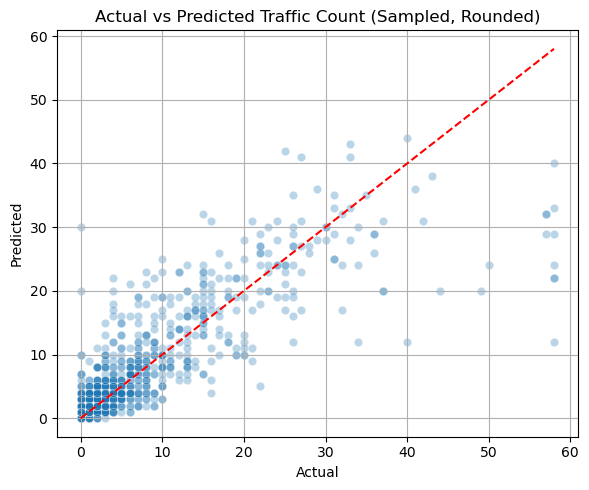

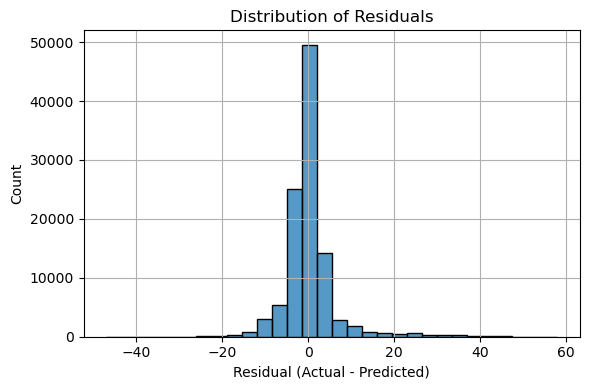

In [40]:
# Install dependencies in Jupyter Notebook (run once if not already installed)
#!pip install xgboost pandas numpy scikit-learn seaborn matplotlib

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from xgboost import XGBRegressor
import seaborn as sns
import matplotlib.pyplot as plt

# Ensure plots display in Jupyter
%matplotlib inline

def time_of_day(hour):
    if 6 <= hour < 12:
        return 'morning'
    elif 12 <= hour < 17:
        return 'afternoon'
    elif 17 <= hour < 21:
        return 'evening'
    else:
        return 'night'

def prepare_ml_data(df):
    df_ml = df[df['property'] == "in_count"].copy()
    
    # Handle missing values
    df_ml = df_ml.dropna(subset=['year', 'month', 'day', 'hour', 'generated_by', 'vehicle_diff', 'ts_generation'])
    
    # Temporal features
    df_ml['weekday'] = df_ml['ts_generation'].dt.weekday
    df_ml['is_weekend'] = df_ml['weekday'].isin([5, 6]).astype(int)
    df_ml['is_rush_hour'] = df_ml['hour'].isin([7, 8, 9, 10, 16, 17, 18, 19]).astype(int)
    df_ml['time_of_day'] = df_ml['hour'].apply(time_of_day)
    df_ml = pd.get_dummies(df_ml, columns=['time_of_day'], prefix='tod')
    
    # Features and target (excluding hour_sin, hour_cos, vehicle_diff_lag1)
    feature_columns = ['year', 'month', 'day', 'hour', 'generated_by', 'is_weekend', 'is_rush_hour', 
                       'tod_morning', 'tod_afternoon', 'tod_evening', 'tod_night']
    X = df_ml[feature_columns]
    y = df_ml['vehicle_diff']
    
    # Scale features
    scaler_X = StandardScaler()
    X_scaled = scaler_X.fit_transform(X)
    
    return train_test_split(X_scaled, y, test_size=0.2, random_state=42), scaler_X, feature_columns

def train_and_evaluate_traffic_model(df):
    try:
        (X_train, X_test, y_train, y_test), scaler_X, feature_columns = prepare_ml_data(df)
        
        # Initialize XGBoost model
        model = XGBRegressor(n_estimators=100, max_depth=10, learning_rate=0.1, random_state=42, n_jobs=-1)
        print("Training XGBoost model...")
        
        # Train model
        model.fit(X_train, y_train)
        
        # Predictions
        y_pred = model.predict(X_test)
        y_pred_rounded = np.round(y_pred)  # Round predictions for evaluation
        
        # Metrics
        mae = mean_absolute_error(y_test, y_pred_rounded)
        mse = mean_squared_error(y_test, y_pred_rounded)
        r2 = r2_score(y_test, y_pred_rounded)
        # Fixed MAPE: Clip denominator
        denominators = np.abs(y_test)
        denominators = np.where(denominators < 0.1, 0.1, denominators)
        mape = np.mean(np.abs((y_test - y_pred_rounded) / denominators)) * 100
        # SMAPE for robustness
        smape = np.mean(2 * np.abs(y_test - y_pred_rounded) / (np.abs(y_test) + np.abs(y_pred_rounded) + 1e-10)) * 100
        
        print(f"✅ Model Evaluation Metrics (Rounded Predictions):")
        print(f" - Mean Absolute Error (MAE): {mae:.2f}")
        print(f" - Mean Squared Error (MSE): {mse:.2f}")
        print(f" - R-squared (R²): {r2:.4f}")
        #print(f" - Mean Absolute Percentage Error (MAPE): {mape:.2f}%")
        #print(f" - Symmetric MAPE (SMAPE): {smape:.2f}%")
        
        # Cross-validation
        cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='r2')
        print(f"Cross-validated R²: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
        
        
        # Actual vs Predicted Plot (Sampled)
        sample_size = min(1000, len(y_test))
        sample_idx = np.random.choice(len(y_test), sample_size, replace=False)
        plt.figure(figsize=(6, 5))
        sns.scatterplot(x=y_test.iloc[sample_idx], y=y_pred_rounded[sample_idx], alpha=0.3)
        plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
        plt.title('Actual vs Predicted Traffic Count (Sampled, Rounded)')
        plt.xlabel('Actual')
        plt.ylabel('Predicted')
        plt.grid(True)
        plt.tight_layout()
        plt.show()
        plt.close()
        
        # Residual Plot
        residuals = y_test - y_pred_rounded
        plt.figure(figsize=(6, 4))
        sns.histplot(residuals, bins=30, kde=False)
        plt.title("Distribution of Residuals")
        plt.xlabel("Residual (Actual - Predicted)")
        plt.grid(True)
        plt.tight_layout()
        plt.show()
        plt.close()
        
        return model, scaler_X, feature_columns
    
    except Exception as e:
        print(f"Error during training: {str(e)}")
        return None, None, None

def predict_traffic_counts(model, scaler_X, feature_columns, input_data, df=None):
    if model is None:
        print("No model available for prediction.")
        return
    
    try:
        # Prepare input data
        pred_df = pd.DataFrame(input_data, columns=['year', 'month', 'day', 'hour', 'generated_by'])
        pred_df['weekday'] = pd.to_datetime(pred_df[['year', 'month', 'day']]).dt.weekday
        pred_df['is_weekend'] = pred_df['weekday'].isin([5, 6]).astype(int)
        pred_df['is_rush_hour'] = pred_df['hour'].isin([7, 8, 9, 10, 16, 17, 18, 19]).astype(int)
        pred_df['time_of_day'] = pred_df['hour'].apply(time_of_day)
        pred_df = pd.get_dummies(pred_df, columns=['time_of_day'], prefix='tod')
        
        # Ensure all required columns
        for col in feature_columns:
            if col not in pred_df.columns:
                pred_df[col] = 0
        
        # Scale input
        X_pred = scaler_X.transform(pred_df[feature_columns])
        
        # Predict and round to integers
        predictions = model.predict(X_pred)
        predictions_rounded = np.round(predictions).astype(int)
        
        print("📊 Predicted Traffic Counts:")
        for i, (year, month, day, hour, sensor_id) in enumerate(input_data):
            print(f" - Sensor {sensor_id} on {year}-{month:02d}-{day:02d} at {hour:02d}:00 → Predicted vehicle_count(15-minute interval): {predictions_rounded[i]}")
    
    except Exception as e:
        print(f"Error during prediction: {str(e)}")

# Run the training and evaluation
model, scaler_X, feature_columns = train_and_evaluate_traffic_model(data)

In [41]:
# Example prediction
test_cases = [
    (2025, 12, 1, 8, 48),
    (2025, 12, 1, 12, 54),
    (2025, 12, 1, 18, 54)
]
predict_traffic_counts(model, scaler_X, feature_columns, test_cases, df=data)

📊 Predicted Traffic Counts:
 - Sensor 48 on 2025-12-01 at 08:00 → Predicted vehicle_count(15-minute interval): 35
 - Sensor 54 on 2025-12-01 at 12:00 → Predicted vehicle_count(15-minute interval): 7
 - Sensor 54 on 2025-12-01 at 18:00 → Predicted vehicle_count(15-minute interval): 36


# Traffic Count Prediction Using XGBoost with 70/10/20 Train-Validation-Test Split



2025-07-04 00:15:03,478 - INFO - Preparing data for machine learning...
2025-07-04 00:15:03,750 - INFO - Dataset size after dropping NA: 534946 rows
2025-07-04 00:15:04,705 - INFO - Data split: Train=374461 (70.00%), Validation=53495 (10.00%), Test=106990 (20.00%)
2025-07-04 00:15:04,723 - INFO - Training XGBoost model incrementally...
2025-07-04 00:15:04,951 - INFO -  - Epoch 1: Train RMSE=9.9296, Validation RMSE=9.9422
2025-07-04 00:15:05,219 - INFO -  - Epoch 2: Train RMSE=9.3847, Validation RMSE=9.4027
2025-07-04 00:15:05,521 - INFO -  - Epoch 3: Train RMSE=8.9181, Validation RMSE=8.9415
2025-07-04 00:15:05,868 - INFO -  - Epoch 4: Train RMSE=8.5210, Validation RMSE=8.5483
2025-07-04 00:15:06,270 - INFO -  - Epoch 5: Train RMSE=8.1836, Validation RMSE=8.2160
2025-07-04 00:15:06,687 - INFO -  - Epoch 6: Train RMSE=7.8990, Validation RMSE=7.9360
2025-07-04 00:15:07,147 - INFO -  - Epoch 7: Train RMSE=7.6586, Validation RMSE=7.7005
2025-07-04 00:15:07,703 - INFO -  - Epoch 8: Train RM

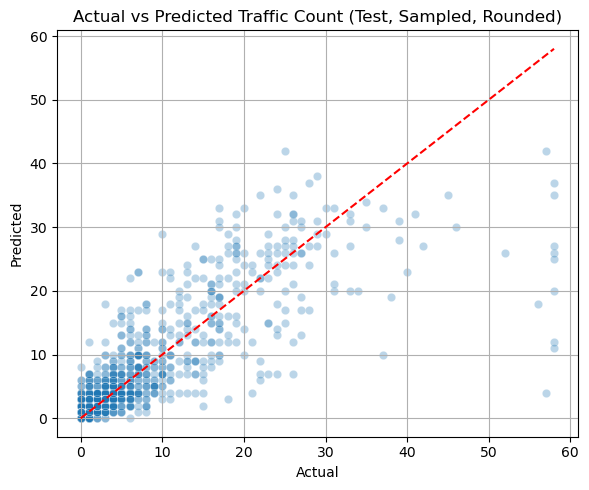

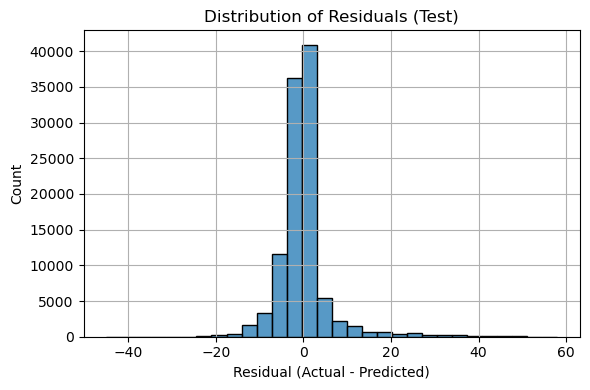

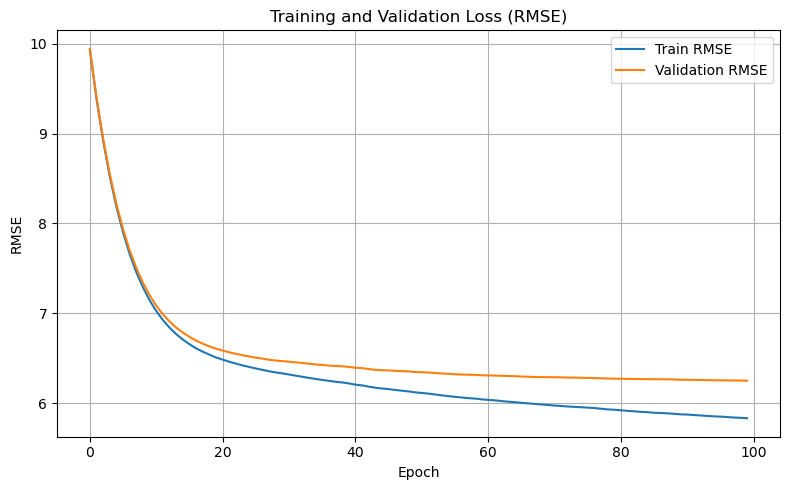

In [42]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from xgboost import XGBRegressor
import seaborn as sns
import matplotlib.pyplot as plt
import logging

# Log XGBoost version
import xgboost
logger = logging.getLogger(__name__)
logger.info(f"XGBoost version: {xgboost.__version__}")

# Set up logging
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')

# Ensure plots display in Jupyter
%matplotlib inline

def time_of_day(hour):
    if 6 <= hour < 12:
        return 'morning'
    elif 12 <= hour < 17:
        return 'afternoon'
    elif 17 <= hour < 21:
        return 'evening'
    else:
        return 'night'

def prepare_ml_data(df):
    logger.info("Preparing data for machine learning...")
    df_ml = df[df['property'] == "in_count"].copy()
    
    # Handle missing values
    df_ml = df_ml.dropna(subset=['year', 'month', 'day', 'hour', 'generated_by', 'vehicle_diff', 'ts_generation'])
    logger.info(f"Dataset size after dropping NA: {df_ml.shape[0]} rows")
    
    # Temporal features
    df_ml['weekday'] = df_ml['ts_generation'].dt.weekday
    df_ml['is_weekend'] = df_ml['weekday'].isin([5, 6]).astype(int)
    df_ml['is_rush_hour'] = df_ml['hour'].isin([7, 8, 9, 10, 16, 17, 18, 19]).astype(int)
    df_ml['time_of_day'] = df_ml['hour'].apply(time_of_day)
    df_ml = pd.get_dummies(df_ml, columns=['time_of_day'], prefix='tod')
    
    # Features and target
    feature_columns = ['year', 'month', 'day', 'hour', 'generated_by', 'is_weekend', 'is_rush_hour', 
                       'tod_morning', 'tod_afternoon', 'tod_evening', 'tod_night']
    X = df_ml[feature_columns]
    y = df_ml['vehicle_diff']
    
    # Ensure non-negative target (just in case)
    y = np.maximum(y, 0)
    
    # Scale features
    scaler_X = StandardScaler()
    X_scaled = scaler_X.fit_transform(X)
    
    # 70/10/20 split
    X_temp, X_test, y_temp, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)
    X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.125, random_state=42)
    logger.info(f"Data split: Train={len(X_train)} ({len(X_train)/len(df_ml):.2%}), Validation={len(X_val)} ({len(X_val)/len(df_ml):.2%}), Test={len(X_test)} ({len(X_test)/len(df_ml):.2%})")
    
    return (X_train, X_val, X_test, y_train, y_val, y_test), scaler_X, feature_columns

def compute_metrics(y_true, y_pred, dataset_name=""):
    # Clip predictions to non-negative
    y_pred_rounded = np.maximum(np.round(y_pred), 0)
    mae = mean_absolute_error(y_true, y_pred_rounded)
    mse = mean_squared_error(y_true, y_pred_rounded)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred_rounded)
    # Improved MAPE to handle zeros
    denominators = np.abs(y_true)
    denominators = np.where(denominators < 1.0, 1.0, denominators)  # Use 1.0 as minimum denominator
    mape = np.mean(np.abs((y_true - y_pred_rounded) / denominators)) * 100
    smape = np.mean(2 * np.abs(y_true - y_pred_rounded) / (np.abs(y_true) + np.abs(y_pred_rounded) + 1e-10)) * 100
    logger.info(f"{dataset_name} Metrics (Rounded, Non-Negative Predictions):")
    logger.info(f" - MAE: {mae:.2f}")
    logger.info(f" - MSE: {mse:.2f}")
    logger.info(f" - RMSE: {rmse:.2f}")
    logger.info(f" - R²: {r2:.4f}")
    logger.info(f" - MAPE: {mape:.2f}%")
    logger.info(f" - SMAPE: {smape:.2f}%")
    return {"mae": mae, "mse": mse, "rmse": rmse, "r2": r2, "mape": mape, "smape": smape}

def train_and_evaluate_traffic_model(df):
    try:
        (X_train, X_val, X_test, y_train, y_val, y_test), scaler_X, feature_columns = prepare_ml_data(df)
        
        # Initialize XGBoost model
        model = XGBRegressor(n_estimators=1, max_depth=10, learning_rate=0.1, random_state=42, n_jobs=-1)
        logger.info("Training XGBoost model incrementally...")
        
        # Manual loop for training to track loss
        n_estimators = 100
        train_rmse = []
        val_rmse = []
        best_val_rmse = float('inf')
        best_model = None
        early_stopping_rounds = 10
        patience_counter = 0
        
        for i in range(n_estimators):
            # Fit model for one tree
            model.fit(X_train, y_train)
            
            # Compute RMSE for training and validation
            train_pred = np.maximum(model.predict(X_train), 0)  # Clip predictions
            val_pred = np.maximum(model.predict(X_val), 0)  # Clip predictions
            train_rmse_i = np.sqrt(mean_squared_error(y_train, train_pred))
            val_rmse_i = np.sqrt(mean_squared_error(y_val, val_pred))
            train_rmse.append(train_rmse_i)
            val_rmse.append(val_rmse_i)
            logger.info(f" - Epoch {i+1}: Train RMSE={train_rmse_i:.4f}, Validation RMSE={val_rmse_i:.4f}")
            
            # Manual early stopping
            if val_rmse_i < best_val_rmse:
                best_val_rmse = val_rmse_i
                best_model = model
                patience_counter = 0
            else:
                patience_counter += 1
                if patience_counter >= early_stopping_rounds:
                    logger.info(f"Early stopping triggered after {i+1} epochs")
                    model = best_model
                    break

            # Update n_estimators for next iteration
            model.n_estimators += 1
        
        # Final predictions and metrics
        y_val_pred = np.maximum(model.predict(X_val), 0)  # Clip predictions
        y_test_pred = np.maximum(model.predict(X_test), 0)  # Clip predictions
        
        logger.info("✅ Evaluating model performance...")
        val_metrics = compute_metrics(y_val, y_val_pred, "Validation")
        test_metrics = compute_metrics(y_test, y_test_pred, "Test")
        
        # Cross-validation on training data
        cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='r2')
        logger.info(f"Cross-validated R²: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
        
        # Plotting
        sample_size = min(1000, len(y_test))
        sample_idx = np.random.choice(len(y_test), sample_size, replace=False)
        plt.figure(figsize=(6, 5))
        sns.scatterplot(x=y_test.iloc[sample_idx], y=np.round(y_test_pred[sample_idx]), alpha=0.3)
        plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
        plt.title('Actual vs Predicted Traffic Count (Test, Sampled, Rounded)')
        plt.xlabel('Actual')
        plt.ylabel('Predicted')
        plt.grid(True)
        plt.tight_layout()
        plt.show()
        plt.close()
        
        residuals = y_test - np.round(y_test_pred)
        plt.figure(figsize=(6, 4))
        sns.histplot(residuals, bins=30, kde=False)
        plt.title("Distribution of Residuals (Test)")
        plt.xlabel("Residual (Actual - Predicted)")
        plt.grid(True)
        plt.tight_layout()
        plt.show()
        plt.close()
        
        # Plot training and validation RMSE
        plt.figure(figsize=(8, 5))
        plt.plot(train_rmse, label='Train RMSE')
        plt.plot(val_rmse, label='Validation RMSE')
        plt.title('Training and Validation Loss (RMSE)')
        plt.xlabel('Epoch')
        plt.ylabel('RMSE')
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show()
        plt.close()
        
        return model, scaler_X, feature_columns
    
    except Exception as e:
        logger.error(f"Error during training: {str(e)}")
        return None, None, None

def predict_traffic_counts(model, scaler_X, feature_columns, input_data, df=None):
    if model is None:
        logger.error("No model available for prediction.")
        return
    
    try:
        pred_df = pd.DataFrame(input_data, columns=['year', 'month', 'day', 'hour', 'generated_by'])
        pred_df['weekday'] = pd.to_datetime(pred_df[['year', 'month', 'day']]).dt.weekday
        pred_df['is_weekend'] = pred_df['weekday'].isin([5, 6]).astype(int)
        pred_df['is_rush_hour'] = pred_df['hour'].isin([7, 8, 9, 10, 16, 17, 18, 19]).astype(int)
        pred_df['time_of_day'] = pred_df['hour'].apply(time_of_day)
        pred_df = pd.get_dummies(pred_df, columns=['time_of_day'], prefix='tod')
        
        for col in feature_columns:
            if col not in pred_df.columns:
                pred_df[col] = 0
        
        X_pred = scaler_X.transform(pred_df[feature_columns])
        predictions = np.maximum(model.predict(X_pred), 0)  # Clip predictions to non-negative
        predictions_rounded = np.round(predictions).astype(int)
        
        logger.info("📊 Predicted Traffic Counts (Rounded, Non-Negative):")
        for i, (year, month, day, hour, sensor_id) in enumerate(input_data):
            logger.info(f" - Sensor {sensor_id} on {year}-{month:02d}-{day:02d} at {hour:02d}:00 → Predicted vehicle_count: {predictions_rounded[i]}")
    
    except Exception as e:
        logger.error(f"Error during prediction: {str(e)}")

# Run the training and evaluation
model, scaler_X, feature_columns = train_and_evaluate_traffic_model(data)

In [43]:
# Example prediction
test_cases = [
    (2025, 12, 1, 8, 54),
    (2025, 12, 1, 12, 54),
    (2025, 12, 1, 18, 54)
]
predict_traffic_counts(model, scaler_X, feature_columns, test_cases, df=data)

2025-07-04 00:18:27,892 - INFO - 📊 Predicted Traffic Counts (Rounded, Non-Negative):
2025-07-04 00:18:27,892 - INFO -  - Sensor 54 on 2025-12-01 at 08:00 → Predicted vehicle_count: 9
2025-07-04 00:18:27,898 - INFO -  - Sensor 54 on 2025-12-01 at 12:00 → Predicted vehicle_count: 10
2025-07-04 00:18:27,900 - INFO -  - Sensor 54 on 2025-12-01 at 18:00 → Predicted vehicle_count: 35


# XGBoost Regressor with a Poisson objective, a Random Forest Classifier for zero detection

Trained zero classifier
Training XGBoost model with Poisson objective...
✅ Model Evaluation Metrics (Test Set):
 - Mean Absolute Error (MAE): 0.36
 - Mean Squared Error (MSE): 0.79
 - R-squared (R²): 0.9915
 - Mean Absolute Percentage Error (MAPE): 6.42%
 - Symmetric MAPE (SMAPE): 6.77%
Cross-validated R²: 0.9914 ± 0.0001


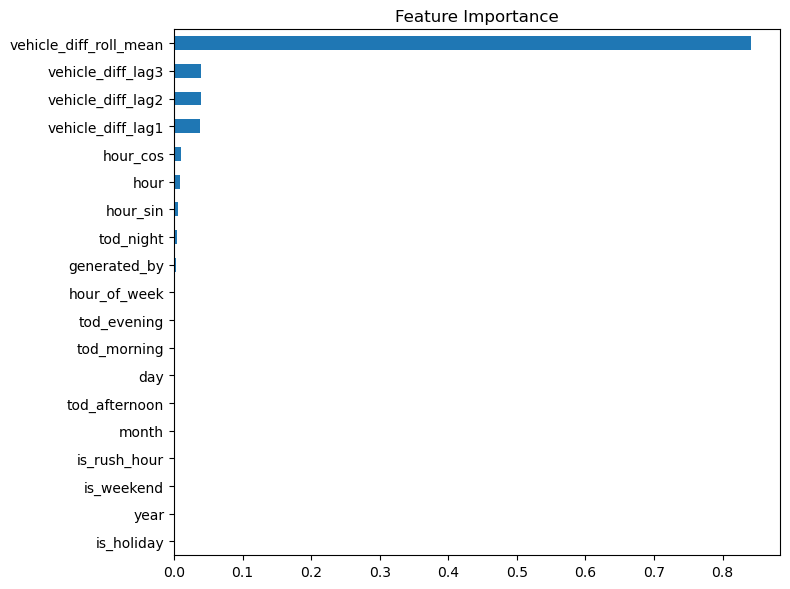

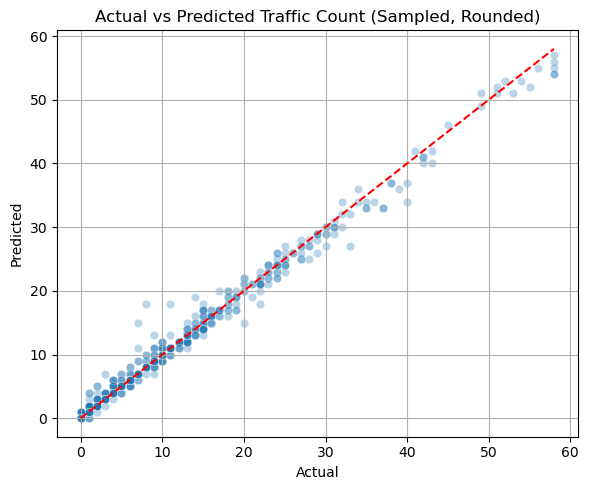

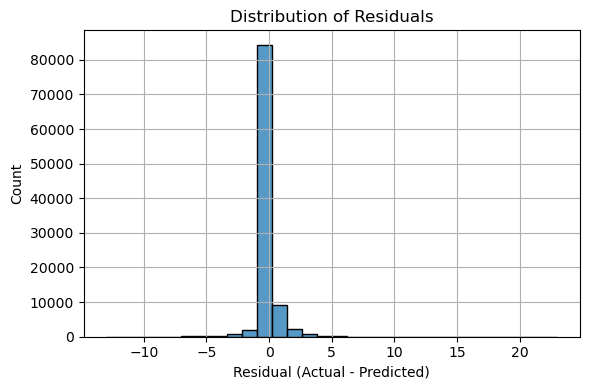

✅ Historical Prediction Metrics for Sensor 54 (2024-01-01 to 2024-01-07):
 - Mean Absolute Error (MAE): 0.44
 - Mean Squared Error (MSE): 0.81
 - R-squared (R²): 0.9880
 - Mean Absolute Percentage Error (MAPE): 11.07%
 - Symmetric MAPE (SMAPE): 12.18%


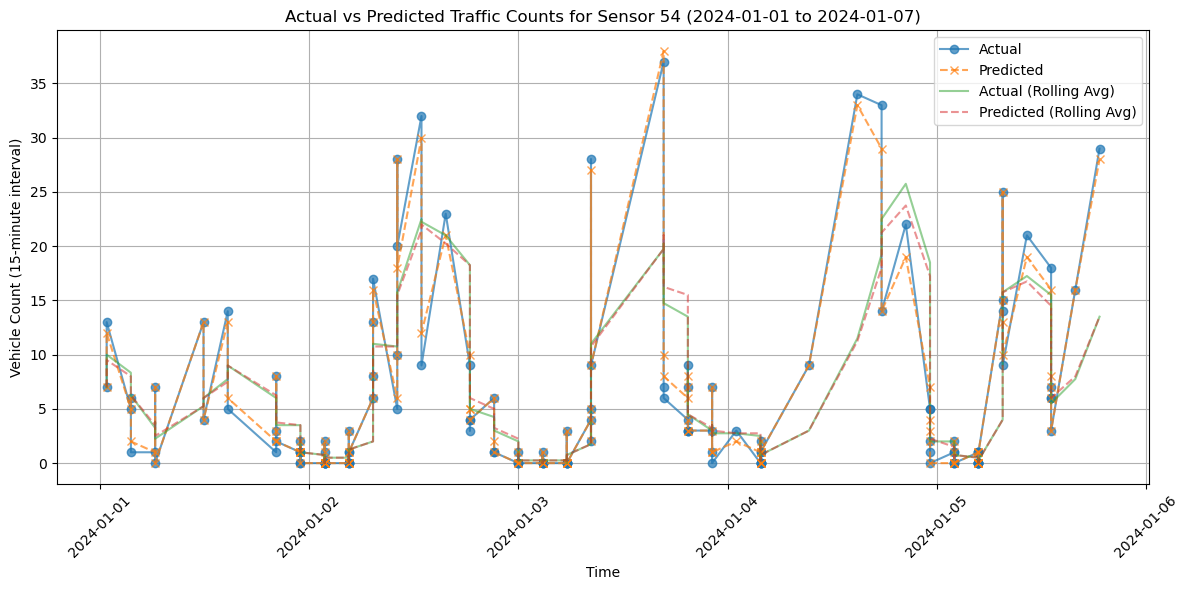

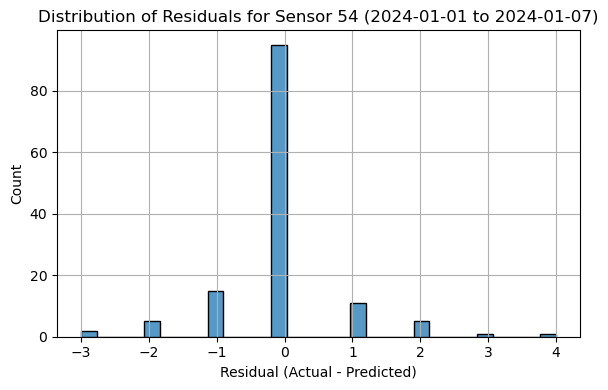


Sample Predictions for Sensor 54:
 - 2024-01-01 14:40 → Actual: 5.0, Predicted: 6
 - 2024-01-04 23:13 → Actual: 2.0, Predicted: 2
 - 2024-01-02 04:33 → Actual: 0.0, Predicted: 0
 - 2024-01-02 21:13 → Actual: 1.0, Predicted: 1
 - 2024-01-05 13:06 → Actual: 18.0, Predicted: 16
📊 Predicted Traffic Counts:
 - Sensor 42 on 2025-12-01 at 08:00 → Predicted vehicle_count(15-minute interval): 30
 - Sensor 54 on 2025-12-01 at 12:00 → Predicted vehicle_count(15-minute interval): 10
 - Sensor 54 on 2025-12-01 at 18:00 → Predicted vehicle_count(15-minute interval): 10


In [44]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBRegressor
import seaborn as sns
import matplotlib.pyplot as plt
from datetime import datetime

# Ensure plots display in Jupyter
%matplotlib inline

def time_of_day(hour):
    if 6 <= hour < 12:
        return 'morning'
    elif 12 <= hour < 17:
        return 'afternoon'
    elif 17 <= hour < 21:
        return 'evening'
    else:
        return 'night'

def is_holiday(date):
    return 1 if (date.month == 1 and date.day == 1) else 0

def prepare_ml_data(df):
    df_ml = df[df['property'] == "in_count"].copy()
    
    # Handle missing values
    df_ml = df_ml.dropna(subset=['year', 'month', 'day', 'hour', 'generated_by', 'vehicle_diff', 'ts_generation'])
    
    # Filter out large time gaps (>1 hour)
    df_ml = df_ml.sort_values(['generated_by', 'ts_generation'])
    time_diffs = df_ml.groupby('generated_by')['ts_generation'].diff().dt.total_seconds() / 60
    df_ml = df_ml[time_diffs.le(60) | time_diffs.isna()].reset_index(drop=True)
    
    # Temporal features
    df_ml['weekday'] = df_ml['ts_generation'].dt.weekday
    df_ml['is_weekend'] = df_ml['weekday'].isin([5, 6]).astype(int)
    df_ml['is_rush_hour'] = df_ml['hour'].isin([7, 8, 9, 10, 16, 17, 18, 19]).astype(int)
    df_ml['time_of_day'] = df_ml['hour'].apply(time_of_day)
    df_ml['is_holiday'] = df_ml['ts_generation'].apply(is_holiday)
    df_ml['hour_of_week'] = df_ml['weekday'] * 24 + df_ml['hour']
    df_ml = pd.get_dummies(df_ml, columns=['time_of_day'], prefix='tod')
    
    # Cyclic encoding
    df_ml['hour_sin'] = np.sin(2 * np.pi * df_ml['hour'] / 24)
    df_ml['hour_cos'] = np.cos(2 * np.pi * df_ml['hour'] / 24)
    
    # Lagged and rolling features
    df_ml['vehicle_diff_lag1'] = df_ml.groupby('generated_by')['vehicle_diff'].shift(1).fillna(0)
    df_ml['vehicle_diff_lag2'] = df_ml.groupby('generated_by')['vehicle_diff'].shift(2).fillna(0)
    df_ml['vehicle_diff_lag3'] = df_ml.groupby('generated_by')['vehicle_diff'].shift(3).fillna(0)
    df_ml['vehicle_diff_roll_mean'] = df_ml.groupby('generated_by')['vehicle_diff'].rolling(window=4, min_periods=1).mean().reset_index(level=0, drop=True).fillna(0)
    
    # Features and target
    feature_columns = ['year', 'month', 'day', 'hour', 'generated_by', 'is_weekend', 'is_rush_hour', 
                       'tod_morning', 'tod_afternoon', 'tod_evening', 'tod_night', 
                       'hour_sin', 'hour_cos', 'vehicle_diff_lag1', 'vehicle_diff_lag2', 
                       'vehicle_diff_lag3', 'vehicle_diff_roll_mean', 'is_holiday', 'hour_of_week']
    X = df_ml[feature_columns]
    y = df_ml['vehicle_diff']
    y_zero = (df_ml['vehicle_diff'] == 0).astype(int)
    
    # Ensure non-negative target
    y = np.maximum(y, 0)
    
    # Scale features
    scaler_X = StandardScaler()
    X_scaled = scaler_X.fit_transform(X)
    
    # Compute historical averages for lagged features
    sensor_avgs = df_ml.groupby(['generated_by', 'hour'])['vehicle_diff'].mean().reset_index()
    
    return train_test_split(X_scaled, y, test_size=0.2, random_state=42), \
           train_test_split(X_scaled, y_zero, test_size=0.2, random_state=42), \
           scaler_X, feature_columns, df_ml, sensor_avgs

def train_and_evaluate_traffic_model(df):
    try:
        (X_train, X_test, y_train, y_test), (X_train_zero, X_test_zero, y_train_zero, y_test_zero), \
        scaler_X, feature_columns, df_ml, sensor_avgs = prepare_ml_data(df)
        
        # Train zero classifier
        clf_zero = RandomForestClassifier(random_state=42, n_jobs=-1)
        clf_zero.fit(X_train_zero, y_train_zero)
        print("Trained zero classifier")
        
        # Train XGBoost model
        model = XGBRegressor(n_estimators=100, max_depth=10, learning_rate=0.1, random_state=42, 
                            n_jobs=-1, objective='count:poisson')
        print("Training XGBoost model with Poisson objective...")
        model.fit(X_train, y_train)
        
        # Predictions
        zero_pred = clf_zero.predict(X_test)
        y_pred = np.maximum(model.predict(X_test), 0)
        y_pred_rounded = np.round(y_pred).astype(int)
        y_pred_rounded[(zero_pred == 1) & (y_pred < 1)] = 0
        
        # Metrics
        mae = mean_absolute_error(y_test, y_pred_rounded)
        mse = mean_squared_error(y_test, y_pred_rounded)
        r2 = r2_score(y_test, y_pred_rounded)
        denominators = np.abs(y_test)
        denominators = np.where(denominators < 1.0, 1.0, denominators)
        mape = np.mean(np.abs((y_test - y_pred_rounded) / denominators)) * 100
        smape = np.mean(2 * np.abs(y_test - y_pred_rounded) / (np.abs(y_test) + np.abs(y_pred_rounded) + 1e-10)) * 100
        
        print(f"✅ Model Evaluation Metrics (Test Set):")
        print(f" - Mean Absolute Error (MAE): {mae:.2f}")
        print(f" - Mean Squared Error (MSE): {mse:.2f}")
        print(f" - R-squared (R²): {r2:.4f}")
        print(f" - Mean Absolute Percentage Error (MAPE): {mape:.2f}%")
        print(f" - Symmetric MAPE (SMAPE): {smape:.2f}%")
        
        # Cross-validation
        cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='r2')
        print(f"Cross-validated R²: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
        
        # Feature importance
        plt.figure(figsize=(8, 6))
        feature_importance = pd.Series(model.feature_importances_, index=feature_columns).sort_values()
        feature_importance.plot(kind='barh')
        plt.title('Feature Importance')
        plt.tight_layout()
        plt.show()
        plt.close()
        
        # Actual vs Predicted Plot
        sample_size = min(1000, len(y_test))
        sample_idx = np.random.choice(len(y_test), sample_size, replace=False)
        plt.figure(figsize=(6, 5))
        sns.scatterplot(x=y_test.iloc[sample_idx], y=y_pred_rounded[sample_idx], alpha=0.3)
        plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
        plt.title('Actual vs Predicted Traffic Count (Sampled, Rounded)')
        plt.xlabel('Actual')
        plt.ylabel('Predicted')
        plt.grid(True)
        plt.tight_layout()
        plt.show()
        plt.close()
        
        # Residual Plot
        residuals = y_test - y_pred_rounded
        plt.figure(figsize=(6, 4))
        sns.histplot(residuals, bins=30, kde=False)
        plt.title("Distribution of Residuals")
        plt.xlabel("Residual (Actual - Predicted)")
        plt.grid(True)
        plt.tight_layout()
        plt.show()
        plt.close()
        
        return model, clf_zero, scaler_X, feature_columns, df_ml, sensor_avgs
    
    except Exception as e:
        print(f"Error during training: {str(e)}")
        return None, None, None, None, None, None

def predict_and_plot_past_traffic(model, clf_zero, scaler_X, feature_columns, df_ml, sensor_id, start_date, end_date):
    try:
        # Filter data
        mask = (df_ml['generated_by'] == sensor_id) & \
               (df_ml['ts_generation'] >= start_date) & \
               (df_ml['ts_generation'] <= end_date)
        past_df = df_ml[mask].copy()
        
        if past_df.empty:
            print(f"No data found for Sensor {sensor_id} between {start_date} and {end_date}")
            return
        
        # Prepare features
        X_past = past_df[feature_columns]
        X_past_scaled = scaler_X.transform(X_past)
        
        # Predict
        zero_pred = clf_zero.predict(X_past_scaled)
        y_actual = past_df['vehicle_diff']
        y_pred = np.maximum(model.predict(X_past_scaled), 0)
        y_pred_rounded = np.round(y_pred).astype(int)
        y_pred_rounded[(zero_pred == 1) & (y_pred < 1)] = 0
        
        # Metrics
        mae = mean_absolute_error(y_actual, y_pred_rounded)
        mse = mean_squared_error(y_actual, y_pred_rounded)
        r2 = r2_score(y_actual, y_pred_rounded)
        denominators = np.abs(y_actual)
        denominators = np.where(denominators < 1.0, 1.0, denominators)
        mape = np.mean(np.abs((y_actual - y_pred_rounded) / denominators)) * 100
        smape = np.mean(2 * np.abs(y_actual - y_pred_rounded) / (np.abs(y_actual) + np.abs(y_pred_rounded) + 1e-10)) * 100
        
        print(f"✅ Historical Prediction Metrics for Sensor {sensor_id} ({start_date} to {end_date}):")
        print(f" - Mean Absolute Error (MAE): {mae:.2f}")
        print(f" - Mean Squared Error (MSE): {mse:.2f}")
        print(f" - R-squared (R²): {r2:.4f}")
        print(f" - Mean Absolute Percentage Error (MAPE): {mape:.2f}%")
        print(f" - Symmetric MAPE (SMAPE): {smape:.2f}%")
        
        # Plot actual vs predicted with rolling average
        plt.figure(figsize=(12, 6))
        plt.plot(past_df['ts_generation'], y_actual, label='Actual', marker='o', linestyle='-', alpha=0.7)
        plt.plot(past_df['ts_generation'], y_pred_rounded, label='Predicted', marker='x', linestyle='--', alpha=0.7)
        rolling_actual = y_actual.rolling(window=4, min_periods=1).mean()
        rolling_pred = pd.Series(y_pred_rounded, index=y_actual.index).rolling(window=4, min_periods=1).mean()
        plt.plot(past_df['ts_generation'], rolling_actual, label='Actual (Rolling Avg)', linestyle='-', alpha=0.5)
        plt.plot(past_df['ts_generation'], rolling_pred, label='Predicted (Rolling Avg)', linestyle='--', alpha=0.5)
        plt.title(f'Actual vs Predicted Traffic Counts for Sensor {sensor_id} ({start_date} to {end_date})')
        plt.xlabel('Time')
        plt.ylabel('Vehicle Count (15-minute interval)')
        plt.legend()
        plt.grid(True)
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()
        plt.close()
        
        # Residual Plot
        residuals = y_actual - y_pred_rounded
        plt.figure(figsize=(6, 4))
        sns.histplot(residuals, bins=30, kde=False)
        plt.title(f"Distribution of Residuals for Sensor {sensor_id} ({start_date} to {end_date})")
        plt.xlabel("Residual (Actual - Predicted)")
        plt.grid(True)
        plt.tight_layout()
        plt.show()
        plt.close()
        
        # Sample predictions
        print(f"\nSample Predictions for Sensor {sensor_id}:")
        sample_indices = np.random.choice(len(past_df), min(5, len(past_df)), replace=False)
        for idx in sample_indices:
            ts = past_df['ts_generation'].iloc[idx]
            actual = y_actual.iloc[idx]
            predicted = y_pred_rounded[idx]
            print(f" - {ts:%Y-%m-%d %H:%M} → Actual: {actual}, Predicted: {predicted}")
    
    except Exception as e:
        print(f"Error during historical prediction: {str(e)}")

def predict_traffic_counts(model, clf_zero, scaler_X, feature_columns, input_data, df_ml, sensor_avgs, df=None):
    if model is None or clf_zero is None:
        print("No model or classifier available for prediction.")
        return
    
    try:
        pred_df = pd.DataFrame(input_data, columns=['year', 'month', 'day', 'hour', 'generated_by'])
        pred_df['weekday'] = pd.to_datetime(pred_df[['year', 'month', 'day']]).dt.weekday
        pred_df['is_weekend'] = pred_df['weekday'].isin([5, 6]).astype(int)
        pred_df['is_rush_hour'] = pred_df['hour'].isin([7, 8, 9, 10, 16, 17, 18, 19]).astype(int)
        pred_df['time_of_day'] = pred_df['hour'].apply(time_of_day)
        pred_df['is_holiday'] = pred_df.apply(lambda x: is_holiday(datetime(x['year'], x['month'], x['day'])), axis=1)
        pred_df['hour_of_week'] = pred_df['weekday'] * 24 + pred_df['hour']
        pred_df = pd.get_dummies(pred_df, columns=['time_of_day'], prefix='tod')
        
        # Cyclic encoding
        pred_df['hour_sin'] = np.sin(2 * np.pi * pred_df['hour'] / 24)
        pred_df['hour_cos'] = np.cos(2 * np.pi * pred_df['hour'] / 24)
        
        # Use historical averages for lagged/rolling features
        for idx, row in pred_df.iterrows():
            sensor_id = row['generated_by']
            hour = row['hour']
            avg = sensor_avgs[(sensor_avgs['generated_by'] == sensor_id) & (sensor_avgs['hour'] == hour)]['vehicle_diff']
            pred_df.at[idx, 'vehicle_diff_lag1'] = avg.iloc[0] if not avg.empty else 0
            pred_df.at[idx, 'vehicle_diff_lag2'] = avg.iloc[0] if not avg.empty else 0
            pred_df.at[idx, 'vehicle_diff_lag3'] = avg.iloc[0] if not avg.empty else 0
            pred_df.at[idx, 'vehicle_diff_roll_mean'] = avg.iloc[0] if not avg.empty else 0
        
        # Ensure all required columns
        for col in feature_columns:
            if col not in pred_df.columns:
                pred_df[col] = 0
        
        X_pred = scaler_X.transform(pred_df[feature_columns])
        zero_pred = clf_zero.predict(X_pred)
        predictions = np.maximum(model.predict(X_pred), 0)
        predictions_rounded = np.round(predictions).astype(int)
        predictions_rounded[(zero_pred == 1) & (predictions < 1)] = 0
        
        print("📊 Predicted Traffic Counts:")
        for i, (year, month, day, hour, sensor_id) in enumerate(input_data):
            print(f" - Sensor {sensor_id} on {year}-{month:02d}-{day:02d} at {hour:02d}:00 → Predicted vehicle_count(15-minute interval): {predictions_rounded[i]}")
    
    except Exception as e:
        print(f"Error during prediction: {str(e)}")

# Run the training and evaluation
model, clf_zero, scaler_X, feature_columns, df_ml, sensor_avgs = train_and_evaluate_traffic_model(data)

# Predict and plot past traffic
predict_and_plot_past_traffic(
    model=model,
    clf_zero=clf_zero,
    scaler_X=scaler_X,
    feature_columns=feature_columns,
    df_ml=df_ml,
    sensor_id=54,
    start_date='2024-01-01',
    end_date='2024-01-07'
)

# Example future prediction
test_cases = [
    (2025, 12, 1, 8, 42),
    (2025, 12, 1, 12, 54),
    (2025, 12, 1, 18, 54)
]
predict_traffic_counts(model, clf_zero, scaler_X, feature_columns, test_cases, df_ml, sensor_avgs, df=data)

## Traffic Classification Model

### Defining Classification Labels

In [45]:
# Define traffic levels based on thresholds
def classify_traffic_level(count):
    if count < 2:
        return "Low"
    elif count <7:
        return "Medium"
    else:
        return "High"

In [46]:
# Add traffic level column
df_clf = data[data['property'] == "in_count"].copy()
df_clf['traffic_level'] = df_clf['vehicle_diff'].apply(classify_traffic_level)

# Display the count of each traffic level
level_counts = df_clf['traffic_level'].value_counts()

print("📊 Final Count of Traffic Levels:")
for level, count in level_counts.items():
    print(f" - {level}: {count} records")

📊 Final Count of Traffic Levels:
 - Medium: 189004 records
 - High: 184795 records
 - Low: 161147 records


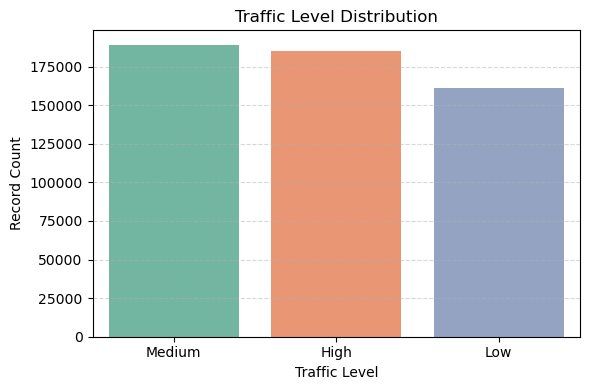

In [47]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 4))
sns.barplot(x=level_counts.index, y=level_counts.values, palette="Set2")
plt.title("Traffic Level Distribution")
plt.xlabel("Traffic Level")
plt.ylabel("Record Count")
plt.tight_layout()
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()


### Preparing Data for Classification

In [48]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

def prepare_classification_data(df):
    df_clf = df[df['property'] == "in_count"].copy()
     # Convert ts_generation to datetime (it's in milliseconds)
    df_clf['ts_generation'] = pd.to_datetime(df_clf['ts_generation'], unit='ms')
    
    # Extract year, month, day, and hour from ts_generation
    df_clf['year'] = df_clf['ts_generation'].dt.year
    df_clf['month'] = df_clf['ts_generation'].dt.month
    df_clf['day'] = df_clf['ts_generation'].dt.day
    df_clf['hour'] = df_clf['ts_generation'].dt.hour
    
    df_clf['traffic_level'] = df_clf['vehicle_diff'].apply(classify_traffic_level)

    #features
    X = df_clf[['year', 'month', 'day', 'hour', 'generated_by']]
    y = df_clf['traffic_level']
    
    return train_test_split(X, y, test_size=0.2, random_state=42)


### Training Classification Model

In [49]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

In [50]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

def train_classification_model(df):
    X_train, X_test, y_train, y_test = prepare_classification_data(df)
    
    clf = RandomForestClassifier(n_estimators=100, random_state=42)
    clf.fit(X_train, y_train)
    
    y_pred = clf.predict(X_test)

    # Evaluation metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

    print("📊 Classification Metrics (Weighted Average):")
    print(f" - Accuracy : {accuracy:.4f}")
    print(f" - Precision: {precision:.4f}")
    print(f" - Recall   : {recall:.4f}")
    print(f" - F1 Score : {f1:.4f}")

    print("\n📄 Detailed Classification Report:")
    print(classification_report(y_test, y_pred, zero_division=0))

    # Confusion matrix
    labels = sorted(list(set(y_test)))  # Get unique class labels
    cm = confusion_matrix(y_test, y_pred, labels=labels)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
    disp.plot(cmap='Blues')
    plt.title("Confusion Matrix - Random Forest")
    plt.grid(False)
    plt.tight_layout()
    plt.show()

    return clf

### Executing the Classification Flow

📊 Classification Metrics (Weighted Average):
 - Accuracy : 0.7028
 - Precision: 0.7048
 - Recall   : 0.7028
 - F1 Score : 0.7037

📄 Detailed Classification Report:
              precision    recall  f1-score   support

        High       0.81      0.79      0.80     36861
         Low       0.71      0.71      0.71     32027
      Medium       0.60      0.62      0.61     38102

    accuracy                           0.70    106990
   macro avg       0.71      0.70      0.71    106990
weighted avg       0.70      0.70      0.70    106990



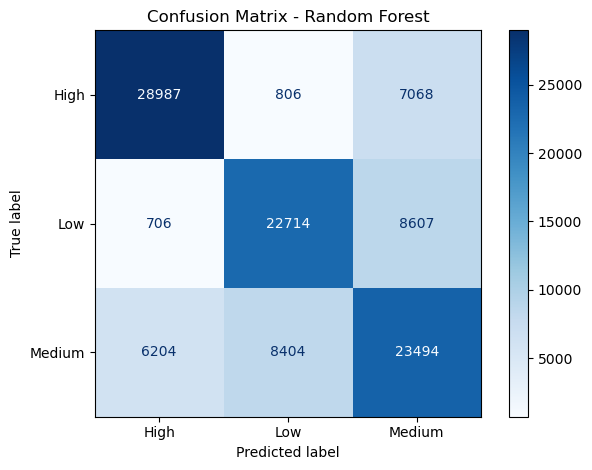

In [51]:
# Train and evaluate the classification model
clf_model = train_classification_model(data)

## Cross-Validation

In [52]:
from sklearn.model_selection import cross_val_score

# Prepare classification data (same logic used in your function)
df_clf = data[data['property'] == "in_count"].copy()
df_clf['traffic_level'] = df_clf['vehicle_diff'].apply(classify_traffic_level)

# Only include non-leaky features
X = df_clf[['year', 'month', 'day', 'hour', 'generated_by']]
y = df_clf['traffic_level']

# Define a new classifier for cross-validation
from sklearn.ensemble import RandomForestClassifier
clf_for_cv = RandomForestClassifier(n_estimators=100, random_state=42)

# Perform 5-fold cross-validation
scores = cross_val_score(clf_for_cv, X, y, cv=5, scoring='f1_weighted')

# Print the average F1 score
print("✅ Cross-validated F1 (Weighted Avg):", scores.mean())


✅ Cross-validated F1 (Weighted Avg): 0.3472573653863166


## Feature Engineering

In [53]:
# Copy the DataFrame
df_clf = data[data['property'] == "in_count"].copy()
df_clf['traffic_level'] = df_clf['vehicle_diff'].apply(classify_traffic_level)

# Feature: is_weekend
df_clf['ts_generation'] = pd.to_datetime(df_clf['ts_generation'])
df_clf['weekday'] = df_clf['ts_generation'].dt.weekday  # Monday = 0, Sunday = 6
df_clf['is_weekend'] = df_clf['weekday'].isin([5, 6]).astype(int)

# Feature: is_rush_hour
df_clf['is_rush_hour'] = df_clf['hour'].between(7, 10) | df_clf['hour'].between(16, 19)
df_clf['is_rush_hour'] = df_clf['is_rush_hour'].astype(int)

# Simulated mapping: sensor_type (urban: 1, highway: 0, unknown: 2)
#sensor_map = {
    #42: 1, 45: 1, 47: 0, 50: 0, 51: 1, 53: 2, 54: 2
#}
#df_clf['sensor_type'] = df_clf['generated_by'].map(sensor_map).fillna(2).astype(int)

# Final features
X = df_clf[['year', 'month', 'day', 'hour', 'generated_by', 'is_weekend', 'is_rush_hour']]
y = df_clf['traffic_level']


## XGBoost Classifier

In [54]:
from xgboost import XGBClassifier
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import LabelEncoder

# Step 1: Encode string labels to numeric
le = LabelEncoder()
y_encoded = le.fit_transform(y)  # Converts ['Low', 'Medium', 'High'] → [0, 1, 2]

# Step 2: Initialize XGBoost Classifier
clf_xgb = XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', scale_pos_weight=None)

# Step 3: Evaluate with 5-fold cross-validation
xgb_scores = cross_val_score(clf_xgb, X, y_encoded, cv=5, scoring='f1_weighted')

# Step 4: Print the result
print(f"✅ XGBoost Cross-validated F1 (Weighted Avg): {xgb_scores.mean():.4f}")

✅ XGBoost Cross-validated F1 (Weighted Avg): 0.4945


# StratifiedKFold

In [55]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder

# Step 1: Encode labels
le = LabelEncoder()
y_encoded = le.fit_transform(y)  # ['Low', 'Medium', 'High'] → [0, 1, 2]

# Step 2: Define Stratified K-Fold
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Step 3: Initialize XGBoost Classifier
clf_xgb = XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42)

# Step 4: Perform cross-validation with stratification
xgb_scores_stratified = cross_val_score(clf_xgb, X, y_encoded, cv=skf, scoring='f1_weighted')

# Step 5: Print results
print("✅ XGBoost Stratified 5-Fold Cross-Validated F1 (Weighted Avg):", xgb_scores_stratified.mean())
print("📊 Per-Fold F1 Scores:", xgb_scores_stratified)


✅ XGBoost Stratified 5-Fold Cross-Validated F1 (Weighted Avg): 0.7372900445519682
📊 Per-Fold F1 Scores: [0.73760392 0.7356327  0.7379818  0.7388566  0.7363752 ]


### Training & Visualizing Per-Class Precision/Recall

📄 Classification Report:

              precision    recall  f1-score   support

        High     0.8424    0.7996    0.8205     36959
         Low     0.7623    0.7186    0.7398     32230
      Medium     0.6254    0.6869    0.6547     37801

    accuracy                         0.7354    106990
   macro avg     0.7433    0.7351    0.7383    106990
weighted avg     0.7416    0.7354    0.7376    106990



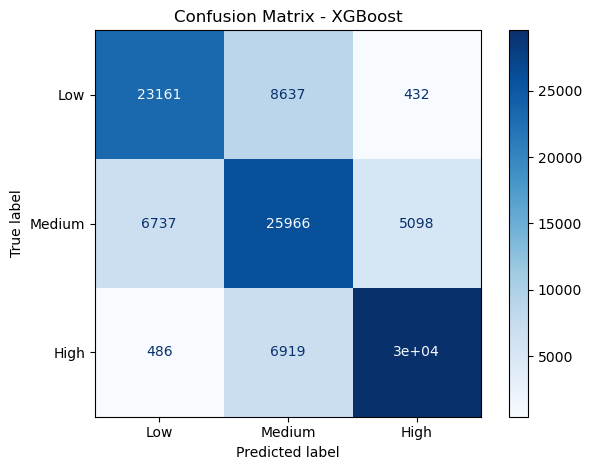

In [56]:
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt

# Step 1: Encode class labels
le = LabelEncoder()
y_encoded = le.fit_transform(y)  # Converts ['Low', 'Medium', 'High'] → [0, 1, 2]

# Step 2: Train-test split using encoded labels
X_train, X_test, y_train_enc, y_test_enc = train_test_split(X, y_encoded, stratify=y_encoded, test_size=0.2, random_state=42)

# Step 3: Train the XGBoost model
clf_xgb.fit(X_train, y_train_enc)

# Step 4: Make predictions
y_pred_enc = clf_xgb.predict(X_test)

# Step 5: Decode labels for report and confusion matrix
y_test = le.inverse_transform(y_test_enc)
y_pred = le.inverse_transform(y_pred_enc)

# Step 6: Classification report
print("📄 Classification Report:\n")
print(classification_report(y_test, y_pred, digits=4))

# Step 7: Confusion Matrix
cm = confusion_matrix(y_test, y_pred, labels=["Low", "Medium", "High"])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Low", "Medium", "High"])
disp.plot(cmap='Blues')
plt.title("Confusion Matrix - XGBoost")
plt.grid(False)
plt.tight_layout()
plt.show()

In [57]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Print four key evaluation metrics (weighted average)
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

print("📊 Key Evaluation Metrics (Weighted Avg):")
print(f" - Accuracy : {accuracy:.4f}")
print(f" - Precision: {precision:.4f}")
print(f" - Recall   : {recall:.4f}")
print(f" - F1 Score : {f1:.4f}")

📊 Key Evaluation Metrics (Weighted Avg):
 - Accuracy : 0.7354
 - Precision: 0.7416
 - Recall   : 0.7354
 - F1 Score : 0.7376


### Predicting Traffic Class for a Future Date and different sensor

In [58]:
def predict_multiple_traffic_classes(clf_model, input_data, label_encoder):
    print("📊 Predicted Traffic Levels (Using XGBoost):")
    for entry in input_data:
        year, month, day, hour, sensor_id = entry

        # Compute is_weekend and is_rush_hour
        timestamp = pd.Timestamp(year=year, month=month, day=day)
        is_weekend = int(timestamp.weekday() in [5, 6])
        is_rush_hour = int(hour in range(7, 11) or hour in range(16, 20))

        # Create input in the order: [year, month, day, hour, sensor_id, is_weekend, is_rush_hour]
        X_input = [[year, month, day, hour, sensor_id, is_weekend, is_rush_hour]]

        # Predict using the model (returns encoded class)
        encoded_pred = clf_model.predict(X_input)

        # Decode label
        predicted_label = label_encoder.inverse_transform(encoded_pred)[0]

        print(f" - Sensor {sensor_id} on {year}-{month:02d}-{day:02d} at {hour:02d}:00 → Predicted Level: {predicted_label}")


In [70]:
test_cases = [
    (2025, 12, 1, 8, 51),
    (2025, 12, 1, 12, 53),
    (2025, 12, 1, 18, 54),
    (2025, 12, 2, 9, 43),
    (2025, 12, 2, 14, 45),
    (2025, 12, 3, 7, 53),
    (2025, 12, 3, 17, 52),
    (2025, 12, 4, 10, 43),
    (2025, 12, 4, 15, 47),
    (2025, 12, 5, 16, 49)
]

In [71]:
predict_multiple_traffic_classes(clf_xgb, test_cases, le)

📊 Predicted Traffic Levels (Using XGBoost):
 - Sensor 51 on 2025-12-01 at 08:00 → Predicted Level: High
 - Sensor 53 on 2025-12-01 at 12:00 → Predicted Level: High
 - Sensor 54 on 2025-12-01 at 18:00 → Predicted Level: High
 - Sensor 43 on 2025-12-02 at 09:00 → Predicted Level: Medium
 - Sensor 45 on 2025-12-02 at 14:00 → Predicted Level: High
 - Sensor 53 on 2025-12-03 at 07:00 → Predicted Level: High
 - Sensor 52 on 2025-12-03 at 17:00 → Predicted Level: High
 - Sensor 43 on 2025-12-04 at 10:00 → Predicted Level: Medium
 - Sensor 47 on 2025-12-04 at 15:00 → Predicted Level: High
 - Sensor 49 on 2025-12-05 at 16:00 → Predicted Level: Medium


# Predicting Speed

### Preparing Speed Data

In [61]:
# Filter only in_avg_time records and compute speed
df_speed = data[data['property'] == 'in_avg_time'].copy()
df_speed = df_speed[df_speed['value'] > 0]  # Avoid divide-by-zero

# Compute speed (3.5 meters divided by avg time in ms → converted to km/h)
df_speed['speed_kmh'] = (3.5 / (df_speed['value'] / 1000)) * 3.6

# Extract temporal features
df_speed['ts_generation'] = pd.to_datetime(df_speed['ts_generation'])
df_speed['year'] = df_speed['ts_generation'].dt.year
df_speed['month'] = df_speed['ts_generation'].dt.month
df_speed['day'] = df_speed['ts_generation'].dt.day
df_speed['hour'] = df_speed['ts_generation'].dt.hour
df_speed['weekday'] = df_speed['ts_generation'].dt.weekday
df_speed['is_weekend'] = df_speed['weekday'].isin([5, 6]).astype(int)
df_speed['is_rush_hour'] = df_speed['hour'].between(7, 10) | df_speed['hour'].between(16, 19)
df_speed['is_rush_hour'] = df_speed['is_rush_hour'].astype(int)
#df_speed['sensor_type'] = df_speed['generated_by'].map(sensor_map).fillna(2).astype(int)


### Training Regression Model to Predict Speed

In [62]:
from sklearn.ensemble import RandomForestRegressor

# Select features and target
X_speed = df_speed[['year', 'month', 'day', 'hour', 'generated_by', 'is_weekend', 'is_rush_hour']]
y_speed = df_speed['speed_kmh']

# Train model
speed_model = RandomForestRegressor(n_estimators=100, random_state=42)
speed_model.fit(X_speed, y_speed)


RandomForestRegressor(random_state=42)

### Predicting Both Traffic Level and Speed

In [63]:
def predict_level_and_speed(classifier_model, speed_model, label_encoder, inputs):
    print("📊 Predicted Traffic Levels and Speeds:")
    for entry in inputs:
        year, month, day, hour, sensor_id = entry
        
        # Feature engineering
        is_weekend = 1 if pd.Timestamp(year, month, day).weekday() >= 5 else 0
        is_rush_hour = 1 if (7 <= hour <= 10) or (16 <= hour <= 19) else 0
        #sensor_type = sensor_map.get(sensor_id, 2)
        
        features = [[year, month, day, hour, sensor_id, is_weekend, is_rush_hour]]
        
        # Predict traffic level
        pred_level_encoded = classifier_model.predict(features)[0]
        pred_level = label_encoder.inverse_transform([pred_level_encoded])[0]
        
        # Predict speed
        pred_speed = speed_model.predict(features)[0]

        print(f" - Sensor {sensor_id} on {year}-{month:02d}-{day:02d} at {hour:02d}:00 → Predicted Level: {pred_level} | Speed: {pred_speed:.2f} km/h")


### Running Prediction on Test Cases

In [72]:
test_cases = [
    (2025, 12, 1, 8, 51),
    (2025, 12, 1, 12, 53),
    (2025, 12, 1, 18, 54),
    (2025, 12, 2, 9, 43),
    (2025, 12, 2, 14, 45),
    (2025, 12, 3, 7, 53),
    (2025, 12, 3, 17, 52),
    (2025, 12, 4, 10, 43),
    (2025, 12, 4, 15, 47),
    (2025, 12, 5, 16, 49)
]

predict_level_and_speed(clf_xgb, speed_model, le, test_cases)


📊 Predicted Traffic Levels and Speeds:
 - Sensor 51 on 2025-12-01 at 08:00 → Predicted Level: High | Speed: 17.70 km/h
 - Sensor 53 on 2025-12-01 at 12:00 → Predicted Level: High | Speed: 19.19 km/h
 - Sensor 54 on 2025-12-01 at 18:00 → Predicted Level: High | Speed: 14.32 km/h
 - Sensor 43 on 2025-12-02 at 09:00 → Predicted Level: Medium | Speed: 27.19 km/h
 - Sensor 45 on 2025-12-02 at 14:00 → Predicted Level: High | Speed: 19.99 km/h
 - Sensor 53 on 2025-12-03 at 07:00 → Predicted Level: High | Speed: 19.82 km/h
 - Sensor 52 on 2025-12-03 at 17:00 → Predicted Level: High | Speed: 14.24 km/h
 - Sensor 43 on 2025-12-04 at 10:00 → Predicted Level: Medium | Speed: 16.79 km/h
 - Sensor 47 on 2025-12-04 at 15:00 → Predicted Level: High | Speed: 18.84 km/h
 - Sensor 49 on 2025-12-05 at 16:00 → Predicted Level: Medium | Speed: 20.56 km/h


## Generating the Plot

In [65]:
def predict_level_and_speed_data(clf_model, speed_model, label_encoder, inputs):
    predictions = []
    for entry in inputs:
        year, month, day, hour, sensor_id = entry
        
        # Feature engineering
        is_weekend = 1 if pd.Timestamp(year, month, day).weekday() >= 5 else 0
        is_rush_hour = 1 if (7 <= hour <= 10) or (16 <= hour <= 19) else 0
        #sensor_type = sensor_map.get(sensor_id, 2)
        
        features = [[year, month, day, hour, sensor_id, is_weekend, is_rush_hour]]
        
        # Predict traffic level
        pred_level_encoded = clf_model.predict(features)[0]
        pred_level = label_encoder.inverse_transform([pred_level_encoded])[0]
        
        # Predict speed
        pred_speed = speed_model.predict(features)[0]

        predictions.append({
            "sensor": sensor_id,
            "datetime": f"{year}-{month:02d}-{day:02d} {hour:02d}:00",
            "traffic_level": pred_level,
            "speed_kmh": pred_speed
        })
    return predictions


In [66]:
import pandas as pd

prediction_data = predict_level_and_speed_data(clf_xgb, speed_model, le, test_cases)
df_pred = pd.DataFrame(prediction_data)


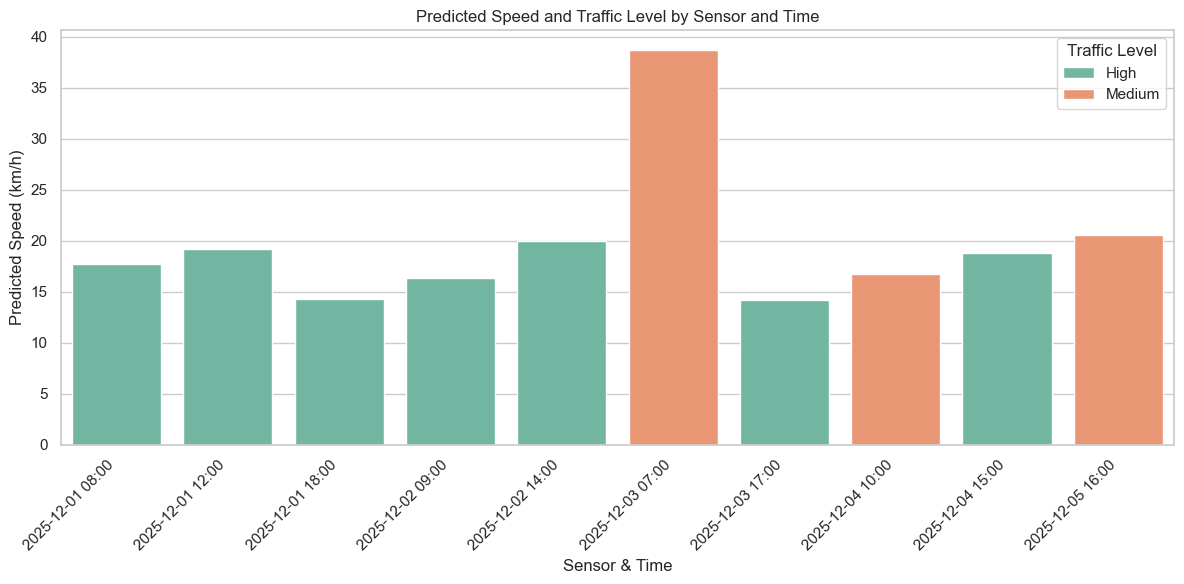

In [67]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set seaborn style
sns.set(style="whitegrid")

# Plot
plt.figure(figsize=(12, 6))
sns.barplot(
    data=df_pred,
    x="datetime",
    y="speed_kmh",
    hue="traffic_level",
    palette="Set2"
)

# Labeling
plt.xticks(rotation=45, ha='right')
plt.ylabel("Predicted Speed (km/h)")
plt.xlabel("Sensor & Time")
plt.title("Predicted Speed and Traffic Level by Sensor and Time")
plt.legend(title="Traffic Level")
plt.tight_layout()
plt.show()


# 4. ROUTE & DIVERSION ANALYSIS

✅ Available Sensors: [53 51 43 42 52 46 44 45 49 47 54]
✅ Analyzing Route: 47 -> 51
✅ Including Additions from Sensors: [54]
📅 Analyzing data from 2023-01-24 00:00:00 to 2023-01-26 23:59:59


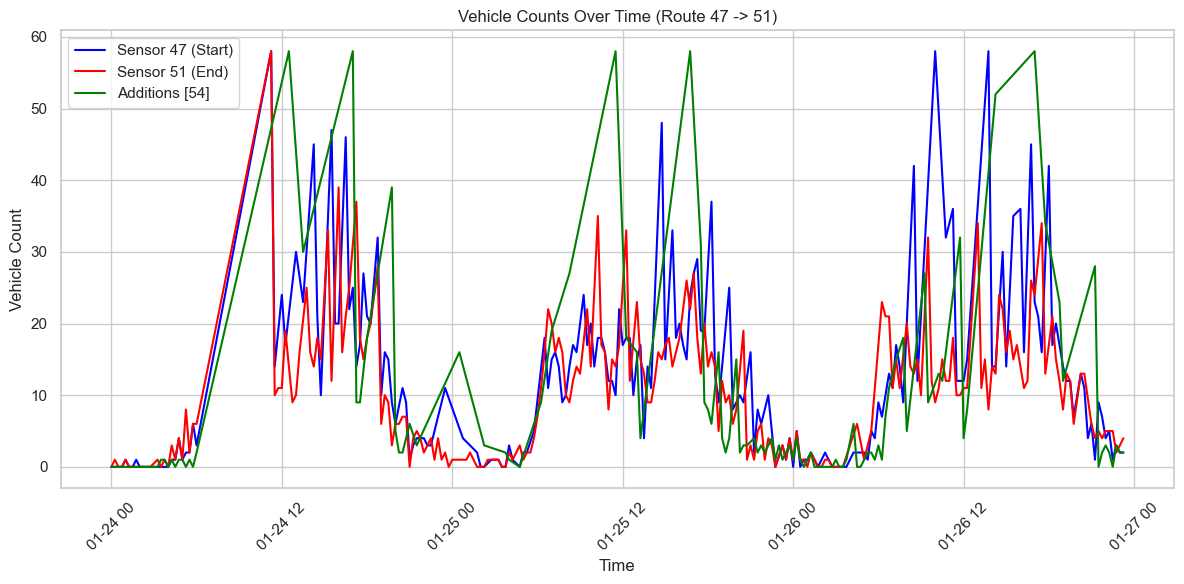

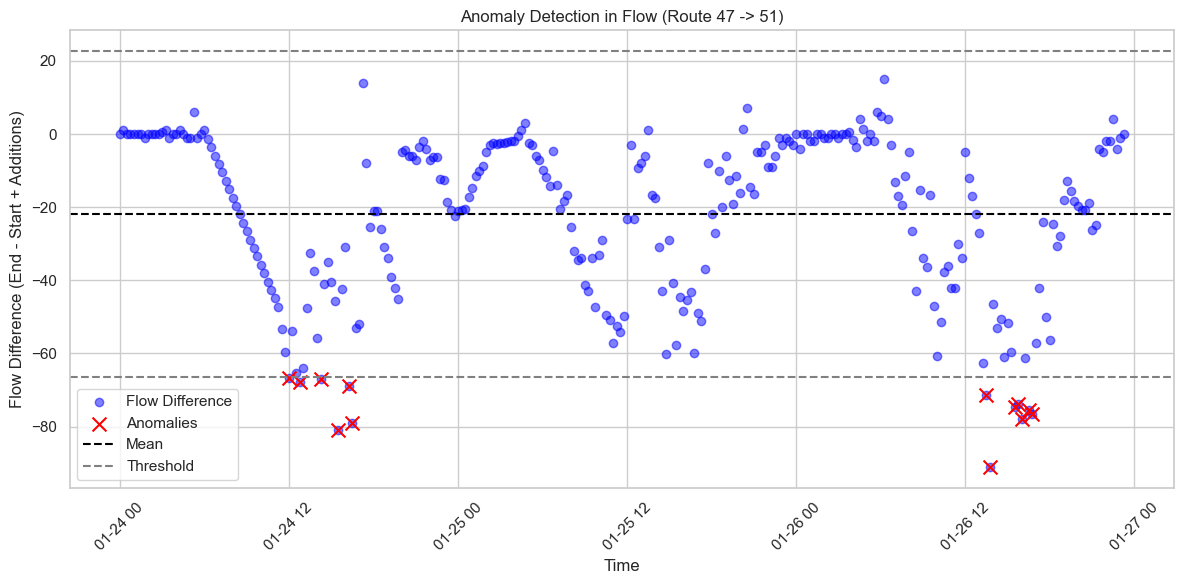


📋 Route Summary:
Route 47 -> 51:
  - Average Flow Difference: -21.93
  - Anomalies Detected: 13
  - Possible Diversion: Vehicle loss between Sensor 47 and Sensor 51. Average flow difference (-21.93) suggests vehicles are diverting.
  - Anomaly Insight: 13 anomalies detected. Types: {'None': 273, 'NegativeDrop': 13}
✅ Results saved as 'route_analysis_47_51.csv'.


In [68]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Function 1: Preprocess Data for a Sensor Pair with Addition Sensors and Time Range Filtering
def preprocess_sensor_data(df, sensor_start, sensor_end, addition_sensors=None, time_tolerance='15min', start_datetime=None, end_datetime=None):
    """
    Preprocess data for a pair of sensors, including additions, aligning timestamps and filtering by time range.
    
    Parameters:
    - df: DataFrame with sensor data
    - sensor_start: Starting sensor ID
    - sensor_end: Ending sensor ID
    - addition_sensors: List of addition sensor IDs (optional)
    - time_tolerance: Time window for resampling (e.g., '15min')
    - start_datetime: Start of the time range (e.g., '2023-01-01 00:00:00')
    - end_datetime: End of the time range (e.g., '2023-12-31 23:59:59')
    
    Returns:
    - Merged DataFrame with aligned timestamps, counts, and additions
    """
    # Filter data for the two sensors
    df_start = df.loc[(df['generated_by'] == sensor_start) & (df['property'] == 'in_count')].copy()
    df_end = df.loc[(df['generated_by'] == sensor_end) & (df['property'] == 'in_count')].copy()

    # Convert timestamps to datetime
    df_start['ts_generation'] = pd.to_datetime(df_start['ts_generation'])
    df_end['ts_generation'] = pd.to_datetime(df_end['ts_generation'])

    # Filter by time range if provided
    if start_datetime:
        start_datetime = pd.to_datetime(start_datetime)
        df_start = df_start[df_start['ts_generation'] >= start_datetime]
        df_end = df_end[df_end['ts_generation'] >= start_datetime]
    if end_datetime:
        end_datetime = pd.to_datetime(end_datetime)
        df_start = df_start[df_start['ts_generation'] <= end_datetime]
        df_end = df_end[df_end['ts_generation'] <= end_datetime]

    # Handle empty data
    if df_start.empty or df_end.empty:
        print(f"🚨 No data for route {sensor_start} -> {sensor_end} within the specified time range. Skipping...")
        return pd.DataFrame()

    # Select relevant columns and sort
    df_start = df_start[['ts_generation', 'vehicle_diff']].sort_values('ts_generation').rename(columns={'vehicle_diff': 'count_start'})
    df_end = df_end[['ts_generation', 'vehicle_diff']].sort_values('ts_generation').rename(columns={'vehicle_diff': 'count_end'})

    # Process addition sensors if provided
    if addition_sensors:
        df_add = df.loc[(df['generated_by'].isin(addition_sensors)) & (df['property'] == 'in_count')].copy()
        df_add['ts_generation'] = pd.to_datetime(df_add['ts_generation'])
        if not df_add.empty:
            df_add = df_add.groupby('ts_generation')['vehicle_diff'].sum().reset_index().rename(columns={'vehicle_diff': 'count_additions'})
        else:
            df_add = pd.DataFrame(columns=['ts_generation', 'count_additions'])
    else:
        df_add = pd.DataFrame(columns=['ts_generation', 'count_additions'])

    # Resample and interpolate to align timestamps
    df_start.set_index('ts_generation', inplace=True)
    df_end.set_index('ts_generation', inplace=True)
    if not df_add.empty:
        df_add.set_index('ts_generation', inplace=True)
        df_add = df_add.resample(time_tolerance).mean().interpolate()
        df_add.reset_index(inplace=True)

    df_start = df_start.resample(time_tolerance).mean().interpolate()
    df_end = df_end.resample(time_tolerance).mean().interpolate()
    df_start.reset_index(inplace=True)
    df_end.reset_index(inplace=True)

    # Merge datasets using nearest timestamp match
    merged = pd.merge_asof(df_start, df_end, on="ts_generation", direction="nearest")
    if not df_add.empty:
        merged = pd.merge_asof(merged, df_add, on="ts_generation", direction="nearest")
        merged['count_additions'] = merged['count_additions'].fillna(0)
    else:
        merged['count_additions'] = 0

    return merged

# Function 2: Analyze Flow and Detect Anomalies with Additions
def analyze_flow_and_anomalies(merged_data, anomaly_threshold=2):
    """
    Analyze flow differences and detect anomalies, accounting for additions.
    """
    if merged_data.empty:
        return merged_data
    
    # Calculate flow difference: count_end - (count_start + count_additions)
    merged_data['flow_diff'] = merged_data['count_end'] - (merged_data['count_start'] + merged_data['count_additions'])
    merged_data.dropna(inplace=True)
    
    if merged_data.empty:
        print("🚨 No matching timestamps after preprocessing.")
        return merged_data
    
    mean_diff = merged_data['flow_diff'].mean()
    std_diff = merged_data['flow_diff'].std()
    threshold = anomaly_threshold * std_diff
    
    merged_data['anomaly'] = (abs(merged_data['flow_diff'] - mean_diff) > threshold).astype(int)
    
    def categorize_anomaly(row, mean_diff, threshold):
        if row['anomaly'] == 0:
            return 'None'
        flow_diff = row['flow_diff']
        if flow_diff - mean_diff > threshold:
            return 'PositiveSpike'
        elif flow_diff - mean_diff < -threshold:
            return 'NegativeDrop'
        return 'None'
    
    merged_data['anomaly_type'] = merged_data.apply(
        lambda row: categorize_anomaly(row, mean_diff, threshold), axis=1
    )
    return merged_data

# Function 3: Visualize Route and Flow
def visualize_route_flow(merged_data, sensor_start, sensor_end, addition_sensors=None, anomaly_threshold=2):
    """
    Visualize vehicle counts and flow differences over time, including additions.
    
    Parameters:
    - merged_data: DataFrame with preprocessed sensor data
    - sensor_start: Starting sensor ID
    - sensor_end: Ending sensor ID
    - addition_sensors: List of addition sensor IDs
    - anomaly_threshold: Threshold for anomaly detection (for plotting)
    """
    if merged_data.empty:
        return
    
    # Line Plot: Vehicle Counts Over Time
    plt.figure(figsize=(12, 6))
    plt.plot(merged_data['ts_generation'], merged_data['count_start'], label=f'Sensor {sensor_start} (Start)', color='blue')
    plt.plot(merged_data['ts_generation'], merged_data['count_end'], label=f'Sensor {sensor_end} (End)', color='red')
    if addition_sensors and merged_data['count_additions'].sum() > 0:
        plt.plot(merged_data['ts_generation'], merged_data['count_additions'], label=f'Additions {addition_sensors}', color='green')
    plt.xlabel('Time')
    plt.ylabel('Vehicle Count')
    plt.title(f'Vehicle Counts Over Time (Route {sensor_start} -> {sensor_end})')
    plt.legend()
    plt.grid(True)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    # Scatter Plot: Anomaly Detection in Flow Difference
    mean_diff = merged_data['flow_diff'].mean()
    std_diff = merged_data['flow_diff'].std()
    threshold = anomaly_threshold * std_diff
    anomalies = merged_data[merged_data['anomaly'] == 1]
    plt.figure(figsize=(12, 6))
    plt.scatter(merged_data['ts_generation'], merged_data['flow_diff'], label='Flow Difference', color='blue', alpha=0.5)
    plt.scatter(anomalies['ts_generation'], anomalies['flow_diff'], color='red', label='Anomalies', marker='x', s=100)
    plt.axhline(mean_diff, color='black', linestyle='--', label='Mean')
    plt.axhline(mean_diff + threshold, color='gray', linestyle='--', label='Threshold')
    plt.axhline(mean_diff - threshold, color='gray', linestyle='--')
    plt.xlabel('Time')
    plt.ylabel('Flow Difference (End - Start + Additions)')
    plt.title(f'Anomaly Detection in Flow (Route {sensor_start} -> {sensor_end})')
    plt.legend()
    plt.grid(True)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# Function 4: Analyze Possible Diversions
def analyze_possible_diversions(merged_data, sensor_start, sensor_end, addition_sensors=None):
    """
    Analyze flow differences to identify diversions, considering additions.
    """
    summary = {}
    if merged_data.empty:
        summary['status'] = "No data"
        return summary
    
    avg_flow_diff = merged_data['flow_diff'].mean()
    anomaly_count = merged_data['anomaly'].sum()
    total_records = len(merged_data)
    
    summary['average_flow_difference'] = avg_flow_diff
    summary['anomaly_count'] = anomaly_count
    summary['total_records'] = total_records
    
    if avg_flow_diff < 0:
        summary['possible_diversion'] = (
            f"Vehicle loss between Sensor {sensor_start} and Sensor {sensor_end}. "
            f"Average flow difference ({avg_flow_diff:.2f}) suggests vehicles are diverting."
        )
    elif avg_flow_diff > 0:
        summary['possible_diversion'] = (
            f"Unexpected vehicle gain between Sensor {sensor_start} and Sensor {sensor_end}. "
            f"Average flow difference ({avg_flow_diff:.2f}) after additions {addition_sensors or []} suggests merging or sensor issues."
        )
    else:
        summary['possible_diversion'] = (
            f"Stable flow between Sensor {sensor_start} and Sensor {sensor_end}. "
            f"Additions {addition_sensors or []} balance the route."
        )
    
    if anomaly_count > 0:
        summary['anomaly_insight'] = (
            f"{anomaly_count} anomalies detected. Types: "
            f"{merged_data['anomaly_type'].value_counts().to_dict()}"
        )
    else:
        summary['anomaly_insight'] = "No anomalies detected in flow."
    
    return summary

# Main Function: Analyze a Single Route with SENSOR_ROUTES
def analyze_routes_and_diversions(df, sensor_start, sensor_end, sensor_routes=None, time_tolerance='30min', anomaly_threshold=2, start_datetime=None, end_datetime=None):
    """
    Analyze a single route (sensor_start -> sensor_end) using SENSOR_ROUTES for additions, within a specific time range.
    
    Parameters:
    - df: DataFrame with sensor data
    - sensor_start: Starting sensor ID
    - sensor_end: Ending sensor ID
    - sensor_routes: Dict of sensor relationships (optional, for validation and additions)
    - time_tolerance: Time window for resampling
    - anomaly_threshold: Threshold for anomaly detection
    - start_datetime: Start of time range
    - end_datetime: End of time range
    
    Returns:
    - DataFrame with analysis for the specified route
    """
    available_sensors = df['generated_by'].unique()
    print(f"✅ Available Sensors: {available_sensors}")

    # Validate sensor_start and sensor_end
    if sensor_start not in available_sensors or sensor_end not in available_sensors:
        print(f"🚨 Sensor {sensor_start} or {sensor_end} not found in dataset.")
        return pd.DataFrame()

    # Validate route against SENSOR_ROUTES if provided
    addition_sensors = None
    if sensor_routes:
        if sensor_start not in sensor_routes or sensor_end not in sensor_routes[sensor_start]['exits']:
            print(f"🚨 Route {sensor_start} -> {sensor_end} not defined in SENSOR_ROUTES.")
            return pd.DataFrame()
        addition_sensors = sensor_routes[sensor_start].get('additions', [])
        # Validate addition sensors
        addition_sensors = [s for s in addition_sensors if s in available_sensors]
        if not addition_sensors:
            addition_sensors = None

    print(f"✅ Analyzing Route: {sensor_start} -> {sensor_end}")
    if addition_sensors:
        print(f"✅ Including Additions from Sensors: {addition_sensors}")
    if start_datetime and end_datetime:
        print(f"📅 Analyzing data from {start_datetime} to {end_datetime}")
    elif start_datetime:
        print(f"📅 Analyzing data from {start_datetime} onwards")
    elif end_datetime:
        print(f"📅 Analyzing data up to {end_datetime}")
    else:
        print("📅 Analyzing all available data")

    # Process the single route
    merged = preprocess_sensor_data(
        df,
        sensor_start,
        sensor_end,
        addition_sensors,
        time_tolerance,
        start_datetime,
        end_datetime
    )
    merged = analyze_flow_and_anomalies(merged, anomaly_threshold)
    
    if merged.empty:
        print(f"🚨 No valid data for route {sensor_start} -> {sensor_end} within the specified time range.")
        return pd.DataFrame()
    
    # Generate visualization and summary
    visualize_route_flow(merged, sensor_start, sensor_end, addition_sensors, anomaly_threshold)
    summary = analyze_possible_diversions(merged, sensor_start, sensor_end, addition_sensors)
    
    print("\n📋 Route Summary:")
    print(f"Route {sensor_start} -> {sensor_end}:")
    print(f"  - Average Flow Difference: {summary.get('average_flow_difference', 0):.2f}")
    print(f"  - Anomalies Detected: {summary.get('anomaly_count', 0)}")
    print(f"  - Possible Diversion: {summary.get('possible_diversion', 'N/A')}")
    print(f"  - Anomaly Insight: {summary.get('anomaly_insight', 'N/A')}")
    
    return merged.reset_index()

# Example Usage
if __name__ == "__main__":
    SENSOR_ROUTES = {
        47: {'exits': [51, 53], 'additions': [54]},
        54: {'exits': [51, 53], 'additions': [47]},
        42: {'exits': [52, 46, 45], 'additions': [43, 49, 44]},
        43: {'exits': [52, 46, 45], 'additions': [42, 49, 44]},
        49: {'exits': [46, 52], 'additions': [43, 42, 44]},
        44: {'exits': [52, 45], 'additions': [49, 43, 42]},
    }
    
    # Assuming 'data' is your preprocessed DataFrame
    sensor_start = 47
    sensor_end = 51
    start_datetime = '2023-01-24 00:00:00'
    end_datetime = '2023-01-26 23:59:59'
    result = analyze_routes_and_diversions(
        data,
        sensor_start=sensor_start,
        sensor_end=sensor_end,
        sensor_routes=SENSOR_ROUTES,
        time_tolerance='15min',
        anomaly_threshold=2,
        start_datetime=start_datetime,
        end_datetime=end_datetime
    )
    if not result.empty:
        result.to_csv(f"route_analysis_{sensor_start}_{sensor_end}.csv", index=False)
        print(f"✅ Results saved as 'route_analysis_{sensor_start}_{sensor_end}.csv'.")

# 5. GEOSPATIAL TRAFFIC VISUALIZATION

In [69]:
import pandas as pd
import folium
from folium.plugins import MarkerCluster
from datetime import date, time
import os

# Define sensor relationships
SENSOR_ROUTES = {
    47: {'exits': [51, 53], 'additions': [54]},
    54: {'exits': [51, 53], 'additions': [47]},
    42: {'exits': [52, 46, 45], 'additions': [43, 49, 44]},
    43: {'exits': [52, 46, 45], 'additions': [42, 49, 44]},
    49: {'exits': [46, 52], 'additions': [43, 42, 44]},
    44: {'exits': [52, 45], 'additions': [49, 43, 42]},
}

# Function to add vehicle_diff column
def add_vehicle_diff(df, threshold=65535):
    df = df.copy()
    df['vehicle_diff'] = np.nan
    in_count_df = df[df['property'] == 'in_count'].copy()
    in_count_df = in_count_df.sort_values(['generated_by', 'ts_generation'])
    for sensor_id, group in in_count_df.groupby('generated_by'):
        values = group['value'].values
        diffs = [0]
        for i in range(1, len(values)):
            diff = values[i] - values[i-1]
            if diff < 0:  # Handle counter reset
                diff = values[i] + (threshold - values[i-1] + 1)
            diffs.append(diff)
        df.loc[group.index, 'vehicle_diff'] = diffs
    return df

# Load data
def load_data():
    files = ["merged_traffic_data_2022.csv", "merged_traffic_data_2023.csv", "merged_traffic_data_2024.csv"]
    data_frames = []
    for file in files:
        if not os.path.exists(file):
            continue
        df = pd.read_csv(file)
        if 'ts_generation' not in df.columns and 'Time' in df.columns:
            df['ts_generation'] = df['Time']
        elif 'ts_generation' in df.columns and 'Time' in df.columns:
            df['ts_generation'] = df['ts_generation'].where(df['ts_generation'].notna(), df['Time'])
        df['ts_generation'] = pd.to_datetime(df['ts_generation'], unit='ms', errors='coerce')
        # Add vehicle_diff column
        df = add_vehicle_diff(df)
        # Now select required columns
        required_columns = ['ts_generation', 'generated_by', 'property', 'vehicle_diff', 'geo_reference']
        df = df[required_columns]
        data_frames.append(df)
    if not data_frames:
        raise ValueError("No data files found.")
    return pd.concat(data_frames, ignore_index=True)

# Parse geo_reference
def parse_geo_reference(geo_ref):
    try:
        if isinstance(geo_ref, str):
            geo_ref = eval(geo_ref)
        return geo_ref['geo_data']['lat'], geo_ref['geo_data']['lon']
    except Exception:
        return None, None

# Print sensor locations
def print_sensor_locations(df, target_sensor=None):
    sensors = df.groupby('generated_by')['geo_reference'].first()
    for sensor, geo in sensors.items():
        if target_sensor is None or sensor in [target_sensor] + SENSOR_ROUTES.get(target_sensor, {}).get('exits', []) + SENSOR_ROUTES.get(target_sensor, {}).get('additions', []):
            lat, lon = parse_geo_reference(geo)
            if lat is not None and lon is not None:
                print(f"Sensor {sensor}: Lat {lat}, Lon {lon}")

# Updated estimate_traffic_patterns to sum vehicle_diff for daily totals
def estimate_traffic_patterns(df, entry_sensor, exit_sensors, addition_sensors, date_range, time_range):
    start_date, end_date = date_range
    start_time, end_time = time_range
    df['date'] = df['ts_generation'].dt.date
    df['time'] = df['ts_generation'].dt.time
    
    df_filtered = df[
        (df['date'].between(start_date, end_date)) &
        (df['ts_generation'].dt.time >= start_time) &
        (df['ts_generation'].dt.time <= end_time) &
        (df['property'] == 'in_count')
    ].copy()
    
    # Compute daily totals by summing vehicle_diff (total vehicles per day)
    daily_totals = df_filtered.groupby(['generated_by', 'date'])['vehicle_diff'].sum().reset_index()
    
    # Entry sensor
    entry_data = daily_totals[daily_totals['generated_by'] == entry_sensor]
    entry_avg = entry_data['vehicle_diff'].mean() if not entry_data.empty else 0
    entry_total = entry_data['vehicle_diff'].sum() if not entry_data.empty else 0
    
    # Exit sensors
    exit_counts = {}
    total_exit_avg = 0
    total_exit_sum = 0
    for exit_sensor in exit_sensors:
        exit_data = daily_totals[daily_totals['generated_by'] == exit_sensor]
        if not exit_data.empty:
            avg_exit = exit_data['vehicle_diff'].mean()
            sum_exit = exit_data['vehicle_diff'].sum()
            exit_counts[exit_sensor] = {'avg': avg_exit, 'total': sum_exit}
            total_exit_avg += avg_exit
            total_exit_sum += sum_exit
        else:
            exit_counts[exit_sensor] = {'avg': 0, 'total': 0}
    
    # Distribution
    distribution = {}
    if total_exit_avg > 0:
        for exit_sensor in exit_sensors:
            proportion = exit_counts[exit_sensor]['avg'] / total_exit_avg
            distribution[exit_sensor] = proportion * 100
    else:
        for exit_sensor in exit_sensors:
            distribution[exit_sensor] = 100 / len(exit_sensors) if exit_sensors else 0
    
    # Additions
    addition_data = daily_totals[daily_totals['generated_by'].isin(addition_sensors)]
    addition_avg = addition_data['vehicle_diff'].mean() if not addition_data.empty else 0
    addition_total = addition_data['vehicle_diff'].sum() if not addition_data.empty else 0
    
    # Observation
    observation = ""
    if entry_avg > 0 and total_exit_avg > 0:
        if total_exit_avg > entry_avg:
            observation = f"Exit counts (avg: {total_exit_avg:.2f}) exceed entry (avg: {entry_avg:.2f}), likely due to additions from sensors {addition_sensors} (avg: {addition_avg:.2f})."
        elif total_exit_avg < entry_avg:
            observation = f"Exit counts (avg: {total_exit_avg:.2f}) lower than entry (avg: {entry_avg:.2f}), possibly due to diversions or insufficient additions from sensors {addition_sensors} (avg: {addition_avg:.2f})."
        else:
            observation = f"Exit counts (avg: {total_exit_avg:.2f}) balanced with entry (avg: {entry_avg:.2f}), stable flow with additions from sensors {addition_sensors} (avg: {addition_avg:.2f})."
    
    return distribution, entry_avg, entry_total, exit_counts, total_exit_avg, total_exit_sum, addition_avg, addition_total, observation

# Plot traffic map
def plot_traffic_map_years(
    df,
    years=[2022, 2023, 2024],
    anomaly_threshold=2,
    date_range=(date(2023, 1, 1), date(2023, 12, 31)),
    time_range=(time(0, 0), time(23, 59)),
    focus_sensor=47
):
    df['ts_generation'] = pd.to_datetime(df['ts_generation'], errors='coerce')
    df = df[df['ts_generation'].dt.year.isin(years)].copy()
    if date_range:
        start_date, end_date = date_range
        df = df[
            (df['ts_generation'].dt.date >= start_date) &
            (df['ts_generation'].dt.date <= end_date)
        ]
    if time_range:
        start_time, end_time = time_range
        df = df[
            (df['ts_generation'].dt.time >= start_time) &
            (df['ts_generation'].dt.time <= end_time)
        ]
    if df.empty:
        print(f"🚨 No data available for sensor {focus_sensor} in the specified range.")
        return None

    df['year'] = df['ts_generation'].dt.year
    df['date'] = df['ts_generation'].dt.date

    sensors = df.groupby('generated_by')['geo_reference'].first().reset_index()
    sensor_locations = {}
    for _, row in sensors.iterrows():
        lat, lon = parse_geo_reference(row['geo_reference'])
        if lat is not None and lon is not None:
            sensor_locations[int(row['generated_by'])] = (lat, lon)

    if not sensor_locations or focus_sensor not in sensor_locations:
        print(f"🚨 No valid location for sensor {focus_sensor}.")
        return None

    folium_map = folium.Map(location=sensor_locations[focus_sensor], zoom_start=14)
    marker_cluster = MarkerCluster().add_to(folium_map)

    # Compute daily totals for stats (also updated to sum vehicle_diff)
    daily_totals = df[df['property'] == 'in_count'].groupby(['generated_by', 'year', 'date'])['vehicle_diff'].sum().reset_index()
    daily_totals = daily_totals.sort_values(['generated_by', 'year', 'date'])
    sensor_yearly_stats = daily_totals.groupby(['generated_by', 'year'])['vehicle_diff'].agg(['mean', 'sum']).reset_index()
    sensor_yearly_stats.rename(columns={'mean': 'avg_vehicles', 'sum': 'total_vehicles'}, inplace=True)

    relevant_sensors = [focus_sensor] + SENSOR_ROUTES.get(focus_sensor, {}).get('exits', []) + SENSOR_ROUTES.get(focus_sensor, {}).get('additions', [])
    for sensor_id in relevant_sensors:
        if sensor_id not in sensor_locations:
            continue
        lat, lon = sensor_locations[sensor_id]
        sensor_data = sensor_yearly_stats[sensor_yearly_stats['generated_by'] == sensor_id]
        popup_text = f"<b>Sensor {sensor_id}</b><br>"
        avg_vehicles_all_years = sensor_data['avg_vehicles'].mean() if not sensor_data.empty else 0
        color = 'red' if avg_vehicles_all_years > 500 else 'orange' if avg_vehicles_all_years > 200 else 'green'

        for year in years:
            year_data = sensor_data[sensor_data['year'] == year]
            if not year_data.empty:
                avg_vehicles = year_data['avg_vehicles'].iloc[0]
                total_vehicles = year_data['total_vehicles'].iloc[0]
                popup_text += f"{year}: Avg Vehicles/Day: {avg_vehicles:.2f}, Total Vehicles: {total_vehicles:.0f}<br>"
            else:
                popup_text += f"{year}: No data<br>"

        if len(sensor_data) > 1:
            trend = sensor_data['avg_vehicles'].pct_change().mean() * 100
            if trend > 10:
                popup_text += "<b>Trend:</b> Traffic increasing significantly.<br>"
            elif trend < -10:
                popup_text += "<b>Trend:</b> Traffic decreasing significantly.<br>"
            else:
                popup_text += "<b>Trend:</b> Traffic relatively stable.<br>"

        folium.Marker(
            location=[lat, lon],
            popup=popup_text,
            icon=folium.Icon(color=color, icon='info-sign')
        ).add_to(marker_cluster)

    # Route analysis (also updated to sum vehicle_diff)
    route_results_by_year = {}
    for year in years:
        df_year = df[(df['year'] == year) & (df['property'] == 'in_count')].copy()
        route_results = {}
        config = SENSOR_ROUTES.get(focus_sensor, {})
        exit_sensors = config.get('exits', [])
        addition_sensors = config.get('additions', [])
        for exit_sensor in exit_sensors:
            df_entry = df_year[df_year['generated_by'] == focus_sensor][['date', 'vehicle_diff']].groupby('date')['vehicle_diff'].sum().reset_index().rename(columns={'vehicle_diff': 'count_entry'})
            df_exit = df_year[df_year['generated_by'] == exit_sensor][['date', 'vehicle_diff']].groupby('date')['vehicle_diff'].sum().reset_index().rename(columns={'vehicle_diff': 'count_exit'})
            df_additions = df_year[df_year['generated_by'].isin(addition_sensors)][['date', 'vehicle_diff']].groupby('date')['vehicle_diff'].sum().reset_index().rename(columns={'vehicle_diff': 'count_additions'})

            if df_entry.empty or df_exit.empty:
                continue

            entry_daily = df_entry
            exit_daily = df_exit
            additions_daily = df_additions if not df_additions.empty else pd.DataFrame(columns=['date', 'count_additions'])

            merged = entry_daily.merge(exit_daily, on='date', how='outer')
            if not additions_daily.empty:
                merged = merged.merge(additions_daily, on='date', how='outer')
            else:
                merged['count_additions'] = 0

            merged['count_entry_diff'] = merged['count_entry'].diff().fillna(merged['count_entry'])
            merged['count_exit_diff'] = merged['count_exit'].diff().fillna(merged['count_exit'])
            merged['count_additions_diff'] = merged['count_additions'].diff().fillna(merged['count_additions'])
            merged = merged[(merged['count_entry_diff'] >= 0) & (merged['count_exit_diff'] >= 0) & (merged['count_additions_diff'] >= 0)]

            merged['flow_diff'] = merged['count_exit_diff'] - merged['count_entry_diff'] + merged['count_additions_diff']
            merged.dropna(subset=['count_entry_diff', 'count_exit_diff'], inplace=True)

            if merged.empty:
                continue

            mean_diff = merged['flow_diff'].mean()
            std_diff = merged['flow_diff'].std()
            threshold = anomaly_threshold * std_diff
            merged['anomaly'] = (abs(merged['flow_diff'] - mean_diff) > threshold).astype(int)
            route_results[f"{focus_sensor}_{exit_sensor}"] = merged

        route_results_by_year[year] = route_results

    for route in set(route for year_routes in route_results_by_year.values() for route in year_routes):
        entry_sensor, exit_sensor = map(int, route.split('_'))
        if entry_sensor == focus_sensor and exit_sensor in sensor_locations:
            start_loc = sensor_locations[entry_sensor]
            end_loc = sensor_locations[exit_sensor]
            popup_text = f"<b>Route {entry_sensor} -> {exit_sensor}</b><br>"
            has_anomalies = False
            avg_flow_diffs = []
            reasons = []

            for year in sorted(years):
                if year in route_results_by_year and route in route_results_by_year[year]:
                    merged = route_results_by_year[year][route]
                    avg_flow_diff = merged['flow_diff'].mean()
                    anomaly_count = merged['anomaly'].sum()
                    popup_text += f"{year}: Avg Flow Diff: {avg_flow_diff:.2f}, Anomalies: {anomaly_count}<br>"
                    if anomaly_count > 0:
                        has_anomalies = True
                        reasons.append(f"{year}: Anomalies detected (possible congestion or sensor issues).")
                    avg_flow_diffs.append(avg_flow_diff)
                else:
                    popup_text += f"{year}: No data<br>"
                    reasons.append(f"{year}: No data available.")

            if len(avg_flow_diffs) > 1:
                trend = pd.Series(avg_flow_diffs).pct_change().mean() * 100
                if trend > 10:
                    reasons.append("Traffic flow difference increasing, possibly due to growing additions or bottlenecks.")
                elif trend < -10:
                    reasons.append("Traffic flow difference decreasing, possibly due to diversions or reduced additions.")
                else:
                    reasons.append("Traffic flow difference stable.")

            config = SENSOR_ROUTES.get(focus_sensor, {})
            addition_sensors = config.get('additions', [])
            if avg_flow_diffs:
                avg_flow_diff = sum(avg_flow_diffs) / len(avg_flow_diffs)
                if avg_flow_diff > 0:
                    reasons.append(f"Increased exit counts likely due to additions from sensors {addition_sensors}.")
                elif avg_flow_diff < 0:
                    reasons.append(f"Decreased exit counts possibly due to diversions or lower additions from sensors {addition_sensors}.")
                else:
                    reasons.append(f"Exit counts balanced, stable contributions from sensors {addition_sensors}.")

            popup_text += "<b>Reasons for Exit Count Changes:</b><br>" + "<br>".join(reasons)

            line_color = 'red' if has_anomalies else 'green'
            line_weight = min(10, max(2, abs(sum(avg_flow_diffs) / len(avg_flow_diffs)) / 1000)) if avg_flow_diffs else 2
            folium.PolyLine(
                locations=[start_loc, end_loc],
                color=line_color,
                weight=line_weight,
                opacity=0.8,
                popup=popup_text
            ).add_to(folium_map)

    config = SENSOR_ROUTES.get(focus_sensor, {})
    exit_sensors = config.get('exits', [])
    addition_sensors = config.get('additions', [])
    distribution, entry_avg, entry_total, exit_counts, total_exit_avg, total_exit_sum, addition_avg, addition_total, observation = estimate_traffic_patterns(
        df,
        focus_sensor,
        exit_sensors,
        addition_sensors,
        date_range,
        time_range
    )

    print(f"\nTraffic Pattern Analysis for Sensor {focus_sensor} ({date_range[0]} to {date_range[1]}, {time_range[0]} to {time_range[1]}):")
    print(f"Average Daily Entry Vehicles (Sensor {focus_sensor}): {entry_avg:.2f}")
    print(f"Total Entry Vehicles (Sensor {focus_sensor}): {entry_total:.0f}")
    print("Average Daily Exit Vehicles:")
    for exit_sensor, counts in exit_counts.items():
        print(f" - Sensor {exit_sensor}: {counts['avg']:.2f} (Proportion: {distribution[exit_sensor]:.2f}%)")
    print(f"Total Average Daily Exit Vehicles: {total_exit_avg:.2f}")
    print(f"Total Exit Vehicles: {total_exit_sum:.0f}")
    print(f"Average Daily Additional Vehicles from Sensors {addition_sensors}: {addition_avg:.2f}")
    print(f"Total Additional Vehicles: {addition_total:.0f}")
    print(f"Observation: {observation}")

    folium_map.save(f"traffic_map_sensor_{focus_sensor}.html")
    print(f"✅ Map saved as 'traffic_map_sensor_{focus_sensor}.html'")
    return folium_map

# Run the function
try:
    data = load_data()
    #print_sensor_locations(data, target_sensor=47)
    for target_sensor in SENSOR_ROUTES.keys():
        print(f"\nRelated Sensors for Sensor {target_sensor}:")
        print_sensor_locations(data, target_sensor=target_sensor)
    map_ = plot_traffic_map_years(
        data,
        years=[2022, 2023, 2024],
        anomaly_threshold=2,
        date_range=(date(2023, 1, 1), date(2023, 12, 31)),
        time_range=(time(0, 0), time(23, 59)),
        focus_sensor=42
    )
except Exception as e:
    print(f"Error running the script: {e}")


Related Sensors for Sensor 47:
Sensor 47: Lat 44.8061743, Lon 10.3077269
Sensor 51: Lat 44.8070729, Lon 10.3080573
Sensor 53: Lat 44.8066223, Lon 10.3097054
Sensor 54: Lat 44.8061599, Lon 10.3096864

Related Sensors for Sensor 54:
Sensor 47: Lat 44.8061743, Lon 10.3077269
Sensor 51: Lat 44.8070729, Lon 10.3080573
Sensor 53: Lat 44.8066223, Lon 10.3097054
Sensor 54: Lat 44.8061599, Lon 10.3096864

Related Sensors for Sensor 42:
Sensor 42: Lat 44.8051062, Lon 10.3120841
Sensor 43: Lat 44.8051181, Lon 10.3128927
Sensor 44: Lat 44.8074511, Lon 10.311935
Sensor 45: Lat 44.8064292, Lon 10.3107388
Sensor 46: Lat 44.8074674, Lon 10.3118891
Sensor 49: Lat 44.8063862, Lon 10.3107331
Sensor 52: Lat 44.8077573, Lon 10.313194

Related Sensors for Sensor 43:
Sensor 42: Lat 44.8051062, Lon 10.3120841
Sensor 43: Lat 44.8051181, Lon 10.3128927
Sensor 44: Lat 44.8074511, Lon 10.311935
Sensor 45: Lat 44.8064292, Lon 10.3107388
Sensor 46: Lat 44.8074674, Lon 10.3118891
Sensor 49: Lat 44.8063862, Lon 10.3